In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

def _resolve_notebook_paths():
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent.parent, cwd.parent]:
        if (candidate / "data" / "raw" / "meteorology" / "uk_temperature_london.csv").exists():
            return candidate
    return cwd.parent.parent if cwd.name == "features" else cwd

PROJECT_ROOT = _resolve_notebook_paths()
NOTEBOOK_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "meteorology"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
METEOROLOGICAL_DIR = PROCESSED_DIR / "meteorological"
PM25_CSV = PROCESSED_DIR / "cleaned_london_marylebone_pm25.csv"

for directory in (RAW_DATA_DIR, METEOROLOGICAL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Meteorological output folder: {METEOROLOGICAL_DIR}")
print(f"Cleaned PM2.5 calendar: {PM25_CSV}")


Raw data folder: /Users/matthewbutler/Documents/MastersPaper/code/features/feature_data
Meteorological output folder: /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological


## Temperature:

Temperature is a common feature across the existing research on PM2.5 prediction. Temperature was found to play the most dominant role in PM2.5 prediction in Zeng et al. (2026; *Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons*).

It has a causal link to pollutant dispersion, so it contains valuable information about how PM2.5 behaves in the atmosphere. Multiple studies highlight temperature inversions during cold winter months as a key factor in PM2.5 pollution events, as the cold air gets trapped under a layer of warmer air, preventing the dispersion of pollutants and leading to higher concentrations of PM2.5 near the ground.

Furthermore, temperature acts as a 'temporal anchor' helping stabilize deep learning models over extended forecast horizons. This is because temperature is a relatively stable and predictable feature, which can help the model learn the underlying patterns in the data and make more accurate predictions over longer time periods. Making it especially important for our use case, as we are predicting PM2.5 levels over long time horizon.

Most papers, sensibly, scale and normalize temperature before feeding it into the model, as this helps the model learn more effectively and prevents it from being biased towards certain ranges of temperature values.

### London / Marylebone Road scale:

We use the HadUK-Grid **London** administrative region as the temperature proxy for London Marylebone Road. HadUK-Grid regional data is not available at individual monitoring-station resolution; London is the closest regional match for Marylebone Road and keeps temperature aligned spatially with our PM2.5 target station.

Daily temperature features are limited to dates present in our cleaned London Marylebone Road PM2.5 series (`data/processed/cleaned_london_marylebone_pm25.csv`), so the meteorological and target series share the same calendar.

#### References:

1. Dominant Predictive Weight

The finding that temperature received the highest attention weight (0.2654) in a Transformer-LSTM model, proving its dominant role in capturing seasonal and diurnal influences, is from:

Zeng, L., Dong, R., Yuan, M., Jing, L., & Jiao, S. (2026). Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons. iScience, 29, 114770.

2. Causal Link to Pollutant Dispersion

The conclusion that meteorological factors like temperature and wind exert a direct causal influence on short-term pollutant dispersion, accumulation, and atmospheric stability is supported by:
Zeng, L., et al. (2026).
Naeini, A. A., Naeini, A. A., Mohammadi, F. K., & Ghaffarpasand, O. Long-Term PM2.5 Forecasting Using a DTW-Enhanced CNN-GRU Model.

3. Predicting Temperature Inversions

The observation that temperature inversions restrict vertical mixing and trap PM2.5 close to the ground—causing severe, short-lived pollution peaks—is highlighted in:

Wood, D. A. (2024). Trend-attribute forecasting of hourly PM2.5 trends in fifteen cities of Central England applying optimized machine learning feature selection. Journal of Environmental Management, 356, 120561.

Naeini, A. A., et al.

Zeng, L., et al. (2026).

4. Stabilizing Long-Term Forecasts
The concept of using auxiliary meteorological features like temperature as "temporal anchors" to prevent model degradation and stabilize long-term predictions (e.g., 10-day forecasts) is discussed in:
Naeini, A. A., et al.

5. Scaling and Normalizing Temperature Data (Note)

The necessity of using Min-Max scaling or normalization on features like temperature so their measurement scales do not bias the neural networks is detailed in:

Patel, P., Patel, S., Shah, K., Desai, K., Patel, S., Shah, M., & Patel, S. (2025). A systematic study on PM2.5 and PM10 concentration prediction in air pollution using machine learning and deep learning model. Environmental Chemistry and Ecotoxicology, 7, 1401–1415.

Naeini, A. A., et al.

Wood, D. A. (2024).


#### Met Office Data

The Met Office provides historical HadUK-Grid temperature data by UK administrative region. We use the **London** region only, as the closest regional proxy for London Marylebone Road.

Fetched with `features/scripts/fetch_uk_temperature.py --region London --output data/uk_temperature_london.csv`.

With the min and max data that the met office provide, we can calculate the average temperature for each day by taking the mean of the maximum and minimum temperatures.

We will also take the min and max temperature readings for each day, as these could provide additional information about the range of temperatures experienced on a given day, which could be relevant for PM2.5 prediction.

tasmax: https://data.ceda.ac.uk/badc/ukmo-hadobs/data/insitu/MOHC/HadOBS/HadUK-Grid/v1.3.2.ceda/region/tasmax/day/v20260512/

tasmin: https://data.ceda.ac.uk/badc/ukmo-hadobs/data/insitu/MOHC/HadOBS/HadUK-Grid/v1.3.2.ceda/region/tasmin/day/v20260512/

Dataset catalogue record: https://catalogue.ceda.ac.uk/uuid/386b3c1ee2054ef5ae0d73060963a9f1/

HadUK-Grid Climate Observations by Administrative Regions over the UK, v1.3.2.ceda (1836-2025)


In [3]:
TEMPERATURE_CSV = RAW_DATA_DIR / 'uk_temperature_london.csv'
temperature_df = pd.read_csv(TEMPERATURE_CSV, parse_dates=['date'])
temperature_df.head()

,date,region,tasmax_c,tasmin_c,source,frequency
0,2016-01-01,London,9.95415,0.78541,ceda_hadukgrid_region,daily
1,2016-01-02,London,10.87211,2.21247,ceda_hadukgrid_region,daily
2,2016-01-03,London,9.04724,4.89992,ceda_hadukgrid_region,daily
3,2016-01-04,London,10.38715,4.78156,ceda_hadukgrid_region,daily
4,2016-01-05,London,10.09688,5.34052,ceda_hadukgrid_region,daily


In [4]:
STATION = 'London Marylebone Road'
REGION = 'London'
PM25_CSV = PROCESSED_DIR / 'cleaned_london_marylebone_pm25.csv'


#### Filtering the temperature data to London:

Our PM2.5 target station is located in London, so we will filter the MET Office temperature data to only include the London administrative region.


In [5]:
# Keep only London regional temperature (proxy for Marylebone Road).
london_temperature_df = temperature_df[temperature_df['region'] == REGION].copy()
london_temperature_df['tasmax_c'] = pd.to_numeric(london_temperature_df['tasmax_c'], errors='coerce')
london_temperature_df['tasmin_c'] = pd.to_numeric(london_temperature_df['tasmin_c'], errors='coerce')

#### Sync up with PM2.5 dates:

Read only the dates from the cleaned PM2.5 dataset, and filter the temperature data to only include those dates. This ensures that the temperature features are aligned with the PM2.5 target series. Duplicate dates are removed (not required for this dataset, but good practice).

In [6]:
pm25_df = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date'])
pm_dates = pm25_df[['date']].drop_duplicates()

Merging the temperature data with the PM2.5 dates ensures that we have a consistent set of features for each date in our target series, which is important for training and evaluating our predictive models.

We only keep the dates that are present in the PM2.5 dataset, which means that any temperature data for dates not present in the PM2.5 dataset will be excluded from our analysis.

In [7]:
london_temperature_df = london_temperature_df.merge(pm_dates, on='date', how='inner')

#### Average temperature:

Use the MET Office provided min and max temperature readings to calculate the average temperature for each day. This is done by taking the mean of the maximum and minimum temperatures.

In [8]:
london_temperature_df['temperature_avg_c'] = london_temperature_df[['tasmax_c', 'tasmin_c']].mean(axis=1)

#### Features table:

Keep the following columns for our daily temperature features:

- date
- tasmax_c (maximum temperature in Celsius) -> renamed: temperature_max_c
- tasmin_c (minimum temperature in Celsius) -> renamed: temperature_min_c
- temperature_avg_c (average temperature in Celsius)

Sort the features by date and reset the index to ensure a clean, sequential index for our dataset.


In [9]:
daily_temperature_features = (
    london_temperature_df[['date', 'tasmax_c', 'tasmin_c', 'temperature_avg_c']]
    .rename(columns={'tasmax_c': 'temperature_max_c', 'tasmin_c': 'temperature_min_c'})
    .sort_values('date')
    .reset_index(drop=True)
)

In [10]:
print(f'Station: {STATION}')
print(f'Region: {REGION}')
print(f'Temperature rows after PM date alignment: {len(daily_temperature_features):,}')
print(f"Date range: {daily_temperature_features['date'].min().date()} to {daily_temperature_features['date'].max().date()}")
daily_temperature_features.head()

Station: London Marylebone Road
Region: London
Temperature rows after PM date alignment: 1,000
Date range: 2022-04-07 to 2024-12-31


,date,temperature_max_c,temperature_min_c,temperature_avg_c
0,2022-04-07,13.59557,6.81938,10.207475
1,2022-04-08,11.34880,1.85679,6.602795
2,2022-04-09,12.37745,0.58838,6.482915
3,2022-04-10,13.32986,-0.20732,6.561270
4,2022-04-11,17.46161,5.02425,11.242930


In [11]:
london_temperature_df['temperature_avg_c'] = london_temperature_df[['tasmax_c', 'tasmin_c']].mean(axis=1)

In [12]:
daily_temperature_features.isnull().sum()

date                 0
temperature_max_c    0
temperature_min_c    0
temperature_avg_c    0
dtype: int64

#### Outliers:

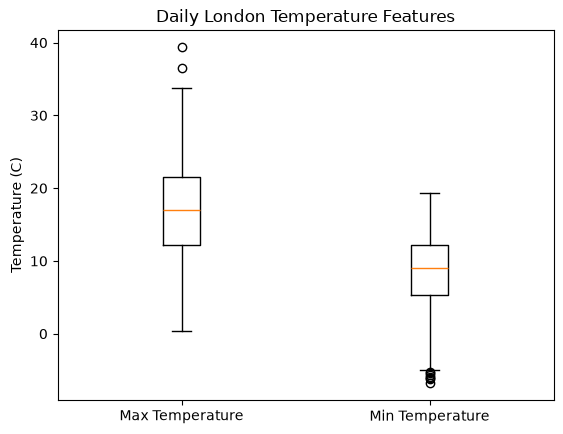

In [13]:
#box plot of the daily temperature features
import matplotlib.pyplot as plt
plt.boxplot([daily_temperature_features['temperature_max_c'],
             daily_temperature_features['temperature_min_c']])
plt.xticks([1, 2], ['Max Temperature', 'Min Temperature'])
plt.ylabel('Temperature (C)')
plt.title('Daily London Temperature Features')
plt.show()

Text(0.5, 1.0, 'Daily London Average Temperature')

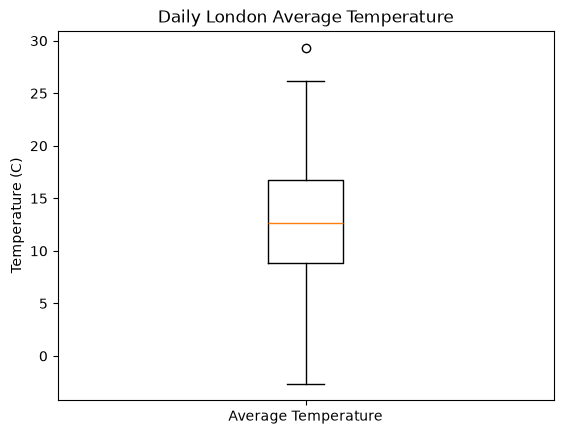

In [14]:
#plot average tempature values in box plot
plt.boxplot(daily_temperature_features['temperature_avg_c'])
plt.xticks([1], ['Average Temperature'])
plt.ylabel('Temperature (C)')
plt.title('Daily London Average Temperature')

In [15]:
def flag_iqr_outliers(df, column, suffix='iqr_outlier'):
    """Return a boolean Series: True if value is outside 1.5 * IQR."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    return (df[column] < lower) | (df[column] > upper)

# Flag outliers in the temperature features and add a new column to the DataFrame for each feature.
for column in ['temperature_max_c', 'temperature_min_c', 'temperature_avg_c']:
    outlier_column = f'{column}_iqr_outlier'
    daily_temperature_features[outlier_column] = flag_iqr_outliers(daily_temperature_features, column)

#get the number of outliers for each temperature feature
outlier_counts = daily_temperature_features[[f'{column}_iqr_outlier' for column in ['temperature_max_c', 'temperature_min_c', 'temperature_avg_c']]].sum()
print('Number of outliers for each temperature feature:')
print(outlier_counts)

Number of outliers for each temperature feature:
temperature_max_c_iqr_outlier    2
temperature_min_c_iqr_outlier    7
temperature_avg_c_iqr_outlier    1
dtype: int64


**Temperature domain outlier sources** (> 50°C max or < −20°C min)

- The [Met Office](https://www.metoffice.gov.uk/about-us/news-and-media/media-centre/weather-and-climate-news/2022/record-high-temperatures-verified) verified the UK's highest recorded daily maximum as **40.3°C** (Coningsby, 19 July 2022), so values above 50°C are treated as data errors rather than real weather.
- The [Met Office](https://www.metoffice.gov.uk/blog/2012/top-ten-coldest-recorded-temperatures-in-the-uk) lists the UK's lowest recorded temperature as **−27.2°C** (Braemar, 10 January 1982); the −20°C lower bound is a generous margin above observed UK minima.
- The [Met Office daily weather extremes page](https://weather.metoffice.gov.uk/observations/weather-extremes) publishes the highest and lowest temperatures recorded across the UK monitoring network each day, confirming that UK daily extremes sit well inside these bounds.


In [16]:
#check for outliers in the daily temperature features (anything above 50C or below -20C)
domain_outlier = daily_temperature_features[(daily_temperature_features['temperature_max_c'] > 50) | 
                                   (daily_temperature_features['temperature_min_c'] < -20)]
print('Outliers in daily temperature features:', len(domain_outlier))
domain_outlier.head()


Outliers in daily temperature features: 0


,date,temperature_max_c,temperature_min_c,temperature_avg_c,temperature_max_c_iqr_outlier,temperature_min_c_iqr_outlier,temperature_avg_c_iqr_outlier


In [17]:
#check alignment of temperature features with PM2.5 data
pm25_df = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date'])
merged_df = pm25_df.merge(daily_temperature_features, on='date', how='left')
missing_temp = merged_df[merged_df['temperature_avg_c'].isnull()]
print('Missing temperature data for PM2.5 dates:', len(missing_temp))

Missing temperature data for PM2.5 dates: 364


#### Missing values:

In [18]:
#check for missing values in the daily temperature features
missing_values = daily_temperature_features.isnull().sum()
print('Missing values in daily temperature features:')
print(missing_values)

Missing values in daily temperature features:
date                             0
temperature_max_c                0
temperature_min_c                0
temperature_avg_c                0
temperature_max_c_iqr_outlier    0
temperature_min_c_iqr_outlier    0
temperature_avg_c_iqr_outlier    0
dtype: int64


In [19]:
OUTPUT_CSV = METEOROLOGICAL_DIR / 'london_temperature_features.csv'
daily_temperature_features.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(daily_temperature_features):,} rows to {OUTPUT_CSV}')

Exported 1,000 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_temperature_features.csv


#### Visualizations:

Scatter plots and Pearson correlations between the daily features in this section and PM2.5 on overlapping dates.


Pearson correlation with PM2.5 (Temperature):
  temperature_max_c: -0.106
  temperature_min_c: -0.251
  temperature_avg_c: -0.178


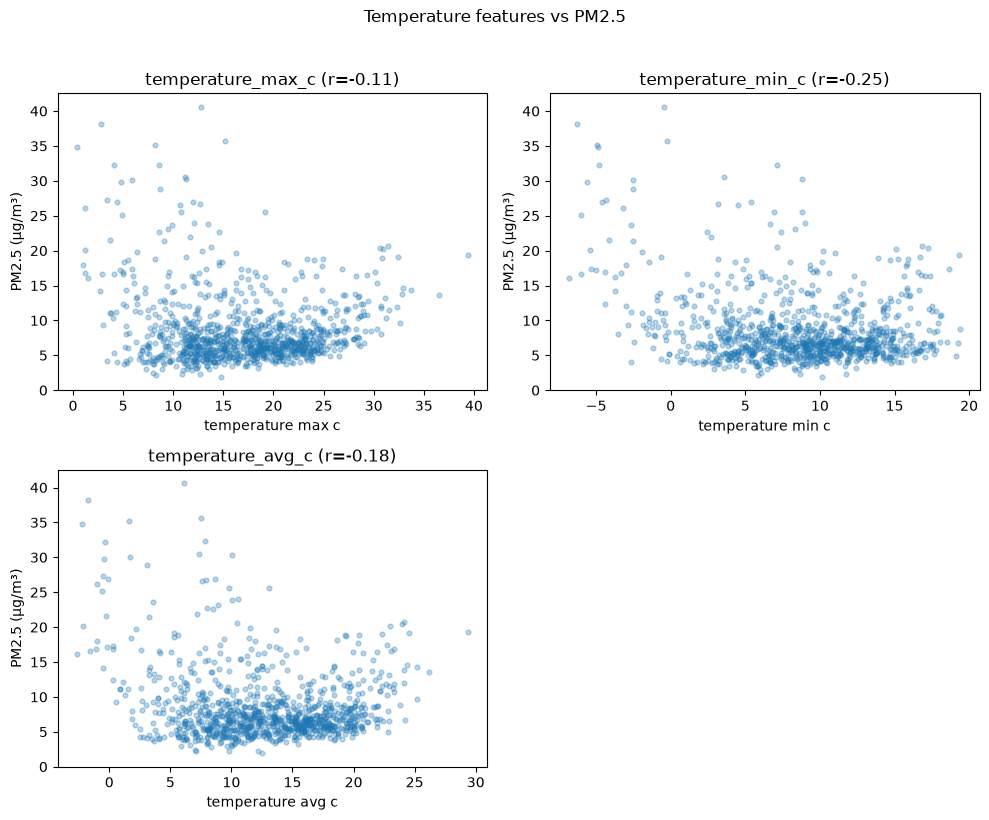

In [20]:
pm25_viz = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date', 'pm25'])
daily_temperature_features_pm = daily_temperature_features.merge(pm25_viz, on='date', how='inner')

feature_cols = ['temperature_max_c', 'temperature_min_c', 'temperature_avg_c']

print('Pearson correlation with PM2.5 (Temperature):')
for col in feature_cols:
    r = daily_temperature_features_pm[col].corr(daily_temperature_features_pm['pm25'])
    print(f'  {col}: {r:.3f}')

n_cols = len(feature_cols)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_cols):
    ax.scatter(daily_temperature_features_pm[col], daily_temperature_features_pm['pm25'], alpha=0.3, s=12)
    r = daily_temperature_features_pm[col].corr(daily_temperature_features_pm['pm25'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{col} (r={r:.2f})')

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Temperature features vs PM2.5', y=1.02)
plt.tight_layout()
plt.show()


## Wind:

Wind speed and direction provide important context for how PM2.5 behaves in the atmosphere. They exert a direct, causal influence on pollutant levels by either diluting the particles or exacerbating their concentration. 

Wind can also serve as a transport mechanism for PM2.5, carrying particles from one location to another, which can affect local air quality and pollution levels. such as dust emitted from agricultural soils which can lead to sudden spikes in PM2.5 levels in urban areas downwind of the source making directional wind data especially important for our use case.

Wind can also help stabilize long term forecasts, as alongside temperature it serves as a temporal anchor, helping the model learn the underlying patterns in the data and make more accurate predictions over longer time periods. Making it especially important for our use case, as we are predicting PM2.5 levels over long time horizons.

#### References:

Stabilizing Long-Term Forecasts: The concept that auxiliary meteorological features, specifically wind speed and wind direction alongside temperature, act as "temporal anchors" to stabilize models and prevent degradation during long-term extrapolations is detailed in:
Naeini, A. A., Naeini, A. A., Mohammadi, F. K., & Ghaffarpasand, O. Long-Term PM2.5 Forecasting Using a DTW-Enhanced CNN-GRU Model.

Tracking Directional Sources: The observation that intermittent winds from specific directions can transport PM2.5 from distinct regional sources (such as wind-eroded agricultural soils or other anthropogenic sources), causing abrupt local elevations, is supported by:
Wood, D. A. (2024). Trend-attribute forecasting of hourly PM2.5 trends in fifteen cities of Central England applying optimized machine learning feature selection. Journal of Environmental Management, 356, 120561.

Driving Dispersion, Transport, and Accumulation: The finding that wind speed and wind direction strongly and directly influence the atmospheric transport and dispersion of PM2.5—and that moderate winds during stagnant periods are a primary contributor to severe accumulation episodes—is discussed in:
Naeini, A. A., Naeini, A. A., Mohammadi, F. K., & Ghaffarpasand, O. Long-Term PM2.5 Forecasting Using a DTW-Enhanced CNN-GRU Model


#### Met Office Data

The Met Office provides MIDAS Open mean wind observations from UK land stations via CEDA. We use **Battersea Heliport** (src_id 62084) as the primary station, the closest MIDAS wind station to London Marylebone Road (~6 km). Hourly mean wind speed (`mean_wind_speed`, knots) and direction (`mean_wind_dir`, degrees true) are aggregated to daily values in the notebook.

Fetched with `features/scripts/fetch_london_wind_battersea.py` → `data/london_wind_hourly.csv`.

uk-mean-wind-obs: https://data.ceda.ac.uk/badc/ukmo-midas-open/data/uk-mean-wind-obs/

Dataset catalogue record: https://catalogue.ceda.ac.uk/uuid/c7393fdc2c974071a2efd7f8601b1bab/

MIDAS Open: UK mean wind data, v202607

Field documentation: https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/WM_Table.html

**Backup station — Kew Gardens** (src_id 723), used to fill Battersea wind gaps. Fetched with `features/scripts/fetch_london_wind_kew_gardens.py` → `data/london_wind_kew_gardens_hourly.csv`. Same MIDAS Open mean wind dataset as above.


In [21]:
#TODO: Write up

In [22]:
wind_df = pd.read_csv(
    RAW_DATA_DIR / 'london_wind_hourly.csv',
    parse_dates=['ob_end_time']
)


In [23]:
wind_df.head()

,ob_end_time,src_id,mean_wind_speed,mean_wind_dir,station_name,source,frequency
0,2018-05-21 00:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
1,2018-05-21 01:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
2,2018-05-21 02:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
3,2018-05-21 03:00:00,62084,1.0,140.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
4,2018-05-21 04:00:00,62084,2.0,140.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly


#### Daily Aggregation:

Our wind data is provided in hourly intervals, but we will aggregate it to daily values to align with our PM2.5 target series. We will create a daily mean average of the `mean_wind_speed` feature in order to capture the overall wind speed conditions for each day. The `mean_wind_dir` will require a special approach to averaging, as it is a circular variable (0 degrees is equivalent to 360 degrees). We will turn each direction into a unit vector (a vector of length 1) and then average the x and y components of these vectors separately on a daily basis. The average wind direction can then be calculated from the averaged x and y components using the `arctan2` function to create a circular mean. 

National Data Buoy Center (NOAA). What averaging procedures are performed on the wind measurements? https://www.ndbc.noaa.gov/wndav.shtml

We will need to create a daily dates column for the wind data, which will be used to group the hourly wind data into daily aggregates. These must align with the `ob_end_time` column in the wind data, which contains the timestamps for each hourly observation. The daily dates column will be created by extracting the date from the `ob_end_time` column and will be used to group the data by day.

In [24]:
wind_df['date'] = pd.to_datetime(wind_df['ob_end_time'], dayfirst=True, format='mixed', errors='coerce').dt.normalize()

In [25]:
wind_df['mean_wind_speed'] = pd.to_numeric(wind_df['mean_wind_speed'], errors='coerce')
wind_df['mean_wind_dir'] = pd.to_numeric(wind_df['mean_wind_dir'], errors='coerce')

These `wind_dir_sin` and `wind_dir_cos` are our unit vector representations of the wind direction, which will be used to calculate the average wind direction for each day. With `wind_dir_sin` being the 'y' component and `wind_dir_cos` being the 'x' component of the representation.

In [26]:
import numpy as np
radians = np.deg2rad(wind_df['mean_wind_dir'])
wind_df['wind_dir_sin'] = np.sin(radians) # y
wind_df['wind_dir_cos'] = np.cos(radians) # x

In [27]:
wind_df.head()

,ob_end_time,src_id,mean_wind_speed,mean_wind_dir,station_name,source,frequency,date,wind_dir_sin,wind_dir_cos
0,2018-05-21 00:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly,2018-05-21,0.766044,-0.642788
1,2018-05-21 01:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly,2018-05-21,0.766044,-0.642788
2,2018-05-21 02:00:00,62084,2.0,130.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly,2018-05-21,0.766044,-0.642788
3,2018-05-21 03:00:00,62084,1.0,140.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly,2018-05-21,0.642788,-0.766044
4,2018-05-21 04:00:00,62084,2.0,140.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly,2018-05-21,0.642788,-0.766044


#### Feature creation:

We will create the following daily wind features:

- `mean_wind_speed_knots`: the average of the hourly `mean_wind_speed` for each day (knots).
- `hourly_obs_count`: the count of hourly observations for each day.
- `wind_speed_max_knots`: the highest hourly `mean_wind_speed` for each day (knots).
- `wind_speed_min_knots`: the lowest hourly `mean_wind_speed` for each day (knots).
- `wind_direction_deg`: daily mean wind direction (degrees true), obtained by averaging hourly direction as unit-vector components (`wind_dir_sin` / `wind_dir_cos`) and converting back to degrees. The sin/cos columns are intermediate only and are not kept in the exported features.

All of these features are calculated by grouping the hourly wind data by date and applying the appropriate aggregation functions (mean, count, max, min).


In [28]:
daily_wind_features = (
    wind_df.groupby('date', as_index=False) # date column is daily, so we will group by this column to get daily aggregates
    .agg(
        mean_wind_speed_knots=('mean_wind_speed', 'mean'), # get the average of the wind speed for the day
        hourly_obs_count=('mean_wind_speed', 'count'), # get the count of hourly observations
        wind_dir_sin=('wind_dir_sin', 'mean'), # get the average of the y component for the day's wind direction
        wind_dir_cos=('wind_dir_cos', 'mean'), # get the average of the x component for the day's wind direction
        wind_speed_max_knots=('mean_wind_speed', 'max'), # highest wind speed of the day
        wind_speed_min_knots=('mean_wind_speed', 'min') # lowest wind speed of the day
    )
)

We must now convert our averaged sin/cos components back into a single wind direction value in degrees. This is done by using the arctan2 function to calculate the angle from the averaged x and y components, and then converting that angle from radians to degrees. The resulting wind direction will be in the range of 0 to 360 degrees (via 360 wrap) and will be the average wind direction for that day. 

In [29]:
daily_wind_features['wind_direction_deg'] = (
    np.rad2deg(np.arctan2(
        daily_wind_features['wind_dir_sin'], # y component
        daily_wind_features['wind_dir_cos'], # x component
    )) + 360
) % 360

In [30]:
daily_wind_features = daily_wind_features.drop(columns=['wind_dir_sin', 'wind_dir_cos'])

In [31]:
daily_wind_features.head()

,date,mean_wind_speed_knots,hourly_obs_count,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
0,2018-05-21,2.375000,24,5.0,1.0,97.671984
1,2018-05-22,6.958333,24,11.0,4.0,19.010117
2,2018-05-23,7.625000,24,10.0,5.0,24.568496
3,2018-05-24,4.541667,24,7.0,2.0,4.251241
4,2018-05-25,3.375000,24,6.0,1.0,326.401697


#### Outlier handling:


Text(0.5, 1.0, 'Daily London Average Wind Speed')

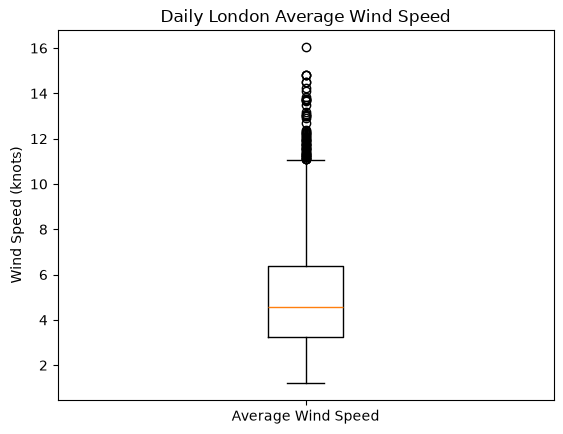

In [32]:
#plot average wind speed values in box plot
plt.boxplot(daily_wind_features['mean_wind_speed_knots'])
plt.xticks([1], ['Average Wind Speed'])
plt.ylabel('Wind Speed (knots)')
plt.title('Daily London Average Wind Speed')

Text(0.5, 1.0, 'Daily London Max and Min Wind Speed')

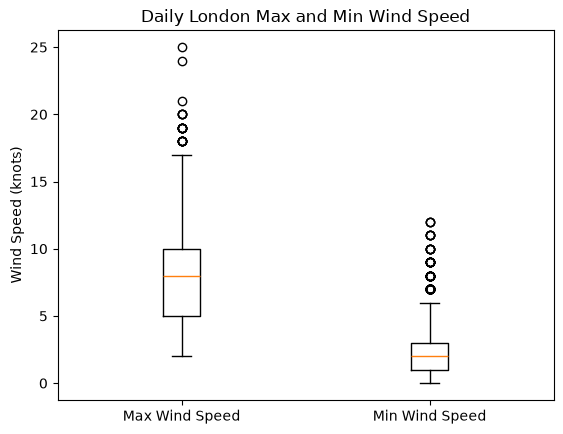

In [33]:
#plot max and min wind speed values in box plot
plt.boxplot([daily_wind_features['wind_speed_max_knots'], daily_wind_features['wind_speed_min_knots']])
plt.xticks([1, 2], ['Max Wind Speed', 'Min Wind Speed'])
plt.ylabel('Wind Speed (knots)')
plt.title('Daily London Max and Min Wind Speed')

In [34]:
def flag_iqr_outliers(df, column, suffix='iqr_outlier'):
    """Return a boolean Series: True if value is outside 1.5 * IQR."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    return (df[column] < lower) | (df[column] > upper)

# one flag column per wind speed feature
daily_wind_features['mean_wind_speed_iqr_outlier'] = flag_iqr_outliers(
    daily_wind_features, 'mean_wind_speed_knots'
)
daily_wind_features['wind_speed_max_iqr_outlier'] = flag_iqr_outliers(
    daily_wind_features, 'wind_speed_max_knots'
)
daily_wind_features['wind_speed_min_iqr_outlier'] = flag_iqr_outliers(
    daily_wind_features, 'wind_speed_min_knots'
)

# optional: single column if ANY speed feature is an IQR outlier
daily_wind_features['wind_speed_iqr_outlier'] = (
    daily_wind_features['mean_wind_speed_iqr_outlier']
    | daily_wind_features['wind_speed_max_iqr_outlier']
    | daily_wind_features['wind_speed_min_iqr_outlier']
)

print('Mean speed IQR outliers:', daily_wind_features['mean_wind_speed_iqr_outlier'].sum())
print('Max speed IQR outliers:', daily_wind_features['wind_speed_max_iqr_outlier'].sum())
print('Min speed IQR outliers:', daily_wind_features['wind_speed_min_iqr_outlier'].sum())
print('Any wind speed IQR outlier:', daily_wind_features['wind_speed_iqr_outlier'].sum())

# inspect flagged rows
daily_wind_features[daily_wind_features['wind_speed_iqr_outlier']].head()

Mean speed IQR outliers: 64
Max speed IQR outliers: 23
Min speed IQR outliers: 93
Any wind speed IQR outlier: 119


,date,mean_wind_speed_knots,hourly_obs_count,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,mean_wind_speed_iqr_outlier,wind_speed_max_iqr_outlier,wind_speed_min_iqr_outlier,wind_speed_iqr_outlier
121,2018-09-19,10.291667,24,20.0,5.0,232.912286,False,True,False,True
122,2018-09-20,10.041667,24,14.0,7.0,230.403220,False,False,True,True
123,2018-09-21,11.291667,24,17.0,7.0,261.133374,True,False,True,True
200,2018-12-07,10.625000,24,14.0,7.0,251.072523,False,False,True,True
201,2018-12-08,12.375000,24,14.0,11.0,255.038076,True,False,True,True


**Wind speed domain outlier sources** (0–40 knots on daily mean speed)

- The [Met Office Beaufort scale](https://weather.metoffice.gov.uk/guides/coast-and-sea/beaufort-scale) defines **Force 8 (Gale)** as **34–40 knots**, giving a meteorological reference for the upper bound on daily mean speed.
- The [Met Office MIDAS user guide](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/ukmo_guide.html) states that UK wind speed is stored in **knots** and that **0 knots** is reported only when conditions are calm over the full hour, so negative speeds are invalid.
- [CEDA's MIDAS Open wind dataset](https://catalogue.ceda.ac.uk/uuid/c7393fdc2c974071a2efd7f8601b1bab/) describes `mean_wind_speed` as the **hourly mean wind speed in knots** from Met Office land stations — the field aggregated to daily values here.


In [35]:
# domain outlier - must be lower than 40 knots and greater than 0 knots
WIND_SPEED_MAX_THRESHOLD = 40 # KNOTS
WIND_SPEED_MIN_THRESHOLD = 0 # KNOTS
if (daily_wind_features['mean_wind_speed_knots'] > WIND_SPEED_MAX_THRESHOLD).any():
    print('mean wind speed exceeds max threshold')
if (daily_wind_features['mean_wind_speed_knots'] < WIND_SPEED_MIN_THRESHOLD).any():
    print('mean wind speed below min threshold')

**Wind direction domain outlier sources** (0–360°)

- The [CEDA UK Mean Wind Data table](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/WM_Table.html) defines `mean_wind_dir` as wind direction in **degrees true** (0–360°).
- The [Met Office MIDAS user guide (§5.5)](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/ukmo_guide.html) specifies that wind direction is measured **clockwise from true north** and reported in **degrees**, so values outside 0–360° indicate a processing or unit error.


In [36]:
# domain outlier - must be between 0 and 360 degrees
WIND_DIRECTION_MAX_THRESHOLD = 360 # DEGREES
WIND_DIRECTION_MIN_THRESHOLD = 0 # DEGREES
if (daily_wind_features['wind_direction_deg'] > WIND_DIRECTION_MAX_THRESHOLD).any():
    print('wind direction exceeds max threshold')
if (daily_wind_features['wind_direction_deg'] < WIND_DIRECTION_MIN_THRESHOLD).any():
    print('wind direction below min threshold')

#### Missing values:

In [37]:
# check for missing values in the daily wind features
missing_values = daily_wind_features.isnull().sum()
print('Missing values in daily wind features:')
print(missing_values)

# check for gaps in date range
date_range = pd.date_range(start=daily_wind_features['date'].min(), end=daily_wind_features['date'].max())
missing_dates = date_range.difference(daily_wind_features['date'])
print('Missing dates in daily wind features:', len(missing_dates))
#print time period of missing dates
if len(missing_dates) > 0:
    print('Missing dates range from', missing_dates.min().date(), 'to', missing_dates.max().date())

daily_wind_features_battersea = daily_wind_features.copy()

Missing values in daily wind features:
date                           0
mean_wind_speed_knots          0
hourly_obs_count               0
wind_speed_max_knots           0
wind_speed_min_knots           0
wind_direction_deg             0
mean_wind_speed_iqr_outlier    0
wind_speed_max_iqr_outlier     0
wind_speed_min_iqr_outlier     0
wind_speed_iqr_outlier         0
dtype: int64
Missing dates in daily wind features: 42
Missing dates range from 2021-10-05 to 2025-05-04


In [38]:
kew_df = pd.read_csv(RAW_DATA_DIR / 'london_wind_kew_gardens_hourly.csv', parse_dates=['ob_end_time'])
kew_dates = pd.to_datetime(kew_df['ob_end_time']).dt.normalize().unique()

battersea_missing = pd.DatetimeIndex(missing_dates)
also_missing_at_kew = battersea_missing[~battersea_missing.isin(kew_dates)]
kew_can_backfill = battersea_missing[battersea_missing.isin(kew_dates)]

print(f'Battersea missing dates: {len(battersea_missing)}')
print(f'Also missing at Kew: {len(also_missing_at_kew)}')
print(f'Kew can backfill: {len(kew_can_backfill)}')
if len(battersea_missing) > 0:
    print(f'Range: {battersea_missing.min().date()} to {battersea_missing.max().date()}')

Battersea missing dates: 42
Also missing at Kew: 0
Kew can backfill: 42
Range: 2021-10-05 to 2025-05-04


#### Kew Gardens, same daily pipeline

Run the same hourly → daily steps on Kew Gardens so it can be compared fairly with Battersea on overlapping dates.


In [39]:
# reuse kew_df from backfill check above
kew_df['date'] = pd.to_datetime(kew_df['ob_end_time'], errors='coerce').dt.normalize() # to daily
kew_df['mean_wind_speed'] = pd.to_numeric(kew_df['mean_wind_speed'], errors='coerce')
kew_df['mean_wind_dir'] = pd.to_numeric(kew_df['mean_wind_dir'], errors='coerce')

kew_radians = np.deg2rad(kew_df['mean_wind_dir'])
kew_df['wind_dir_sin'] = np.sin(kew_radians)
kew_df['wind_dir_cos'] = np.cos(kew_radians)

daily_kew_wind_features = (
    kew_df.groupby('date', as_index=False)
    .agg(
        mean_wind_speed_knots=('mean_wind_speed', 'mean'),
        hourly_obs_count=('mean_wind_speed', 'count'),
        wind_dir_sin=('wind_dir_sin', 'mean'),
        wind_dir_cos=('wind_dir_cos', 'mean'),
        wind_speed_max_knots=('mean_wind_speed', 'max'),
        wind_speed_min_knots=('mean_wind_speed', 'min'),
    )
)

daily_kew_wind_features['wind_direction_deg'] = (
    np.rad2deg(np.arctan2(
        daily_kew_wind_features['wind_dir_sin'],
        daily_kew_wind_features['wind_dir_cos'],
    )) + 360
) % 360

daily_kew_wind_features = daily_kew_wind_features.drop(columns=['wind_dir_sin', 'wind_dir_cos'])
daily_kew_wind_features.head()


,date,mean_wind_speed_knots,hourly_obs_count,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
0,2016-01-01,5.208333,24,9.0,1.0,115.006013
1,2016-01-02,7.625000,24,9.0,5.0,148.636603
2,2016-01-03,5.208333,24,10.0,2.0,186.251476
3,2016-01-04,3.875000,24,5.0,2.0,181.693998
4,2016-01-05,2.125000,24,6.0,0.0,159.994376


In [40]:
daily_kew_wind_features['mean_wind_speed_iqr_outlier'] = flag_iqr_outliers(
    daily_kew_wind_features, 'mean_wind_speed_knots'
)
daily_kew_wind_features['wind_speed_max_iqr_outlier'] = flag_iqr_outliers(
    daily_kew_wind_features, 'wind_speed_max_knots'
)
daily_kew_wind_features['wind_speed_min_iqr_outlier'] = flag_iqr_outliers(
    daily_kew_wind_features, 'wind_speed_min_knots'
)
daily_kew_wind_features['wind_speed_iqr_outlier'] = (
    daily_kew_wind_features['mean_wind_speed_iqr_outlier']
    | daily_kew_wind_features['wind_speed_max_iqr_outlier']
    | daily_kew_wind_features['wind_speed_min_iqr_outlier']
)

kew_date_range = pd.date_range(
    daily_kew_wind_features['date'].min(),
    daily_kew_wind_features['date'].max(),
)
kew_missing_dates = kew_date_range.difference(daily_kew_wind_features['date'])
print('Kew missing daily dates:', len(kew_missing_dates))
if len(kew_missing_dates) > 0:
    print(f'Range: {kew_missing_dates.min().date()} to {kew_missing_dates.max().date()}')

# check outliers in Kew wind features
print('Mean speed IQR outliers:', daily_kew_wind_features['mean_wind_speed_iqr_outlier'].sum())
print('Max speed IQR outliers:', daily_kew_wind_features['wind_speed_max_iqr_outlier'].sum())
print('Min speed IQR outliers:', daily_kew_wind_features['wind_speed_min_iqr_outlier'].sum())


Kew missing daily dates: 59
Range: 2016-10-20 to 2025-07-14
Mean speed IQR outliers: 73
Max speed IQR outliers: 106
Min speed IQR outliers: 35


#### Compare Battersea vs Kew (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.


Kew Gardens is the closest available Met Office station to Battersea. We can assess the quality of the Kew Gardens wind data by comparing it to Battersea on overlapping dates. This will help us determine if Kew Gardens is a suitable proxy for Battersea in our PM2.5 prediction model, if it is, we can use it to fill in missing Battersea wind data on dates where Kew Gardens has valid readings. This is important because having a complete set of wind features is crucial for accurate PM2.5 prediction, and using Kew Gardens as a proxy can help us achieve that.


Overlap days (PM calendar): 1,290
Mean speed correlation: 0.742
Mean bias (Battersea - Kew): 0.67 knots
RMSE: 1.67 knots


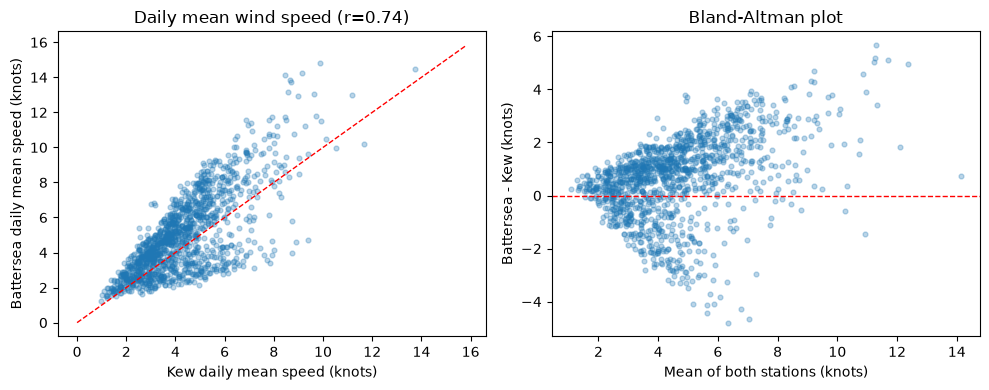

In [41]:
wind_compare = (
    pm_dates
    .merge(daily_wind_features_battersea, on='date', how='inner')
    .merge(daily_kew_wind_features, on='date', how='inner', suffixes=('_battersea', '_kew'))
)

b_speed = wind_compare['mean_wind_speed_knots_battersea']
k_speed = wind_compare['mean_wind_speed_knots_kew']
bias = (b_speed - k_speed).mean()
rmse = np.sqrt(((b_speed - k_speed) ** 2).mean())
corr = b_speed.corr(k_speed)

print(f'Overlap days (PM calendar): {len(wind_compare):,}')
print(f'Mean speed correlation: {corr:.3f}')
print(f'Mean bias (Battersea - Kew): {bias:.2f} knots')
print(f'RMSE: {rmse:.2f} knots')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(k_speed, b_speed, alpha=0.3, s=12)
lim = max(b_speed.max(), k_speed.max()) + 1
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Kew daily mean speed (knots)')
axes[0].set_ylabel('Battersea daily mean speed (knots)')
axes[0].set_title(f'Daily mean wind speed (r={corr:.2f})')

mean_speed = (b_speed + k_speed) / 2
diff = b_speed - k_speed
axes[1].scatter(mean_speed, diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Mean of both stations (knots)')
axes[1].set_ylabel('Battersea - Kew (knots)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()


#### Kew Vs Battersea Wind Speed Comparison:


Kew Gardens has over 1,291 days of overlapping wind data with Battersea, which is a substantial amount of data to compare and assess the quality of the Kew Gardens wind features.

The correlation between the two stations is `0.742`, this is a strong positive correlation, indicating that the wind features from Kew Gardens are likely to be a good proxy for Battersea. Although it won't be perfect, it is a reasonable assumption that the wind features from Kew Gardens can be used to fill in missing Battersea wind data on dates where Kew Gardens has valid readings. 

The bias is `0.67` knots, which is the average difference between the wind speeds recorded at Kew Gardens and Battersea. This indicates that on average, Battersea records slightly higher wind speeds than Kew Gardens. However, this bias is relatively small and manageable given this data will only be used for `2.49%` of the PM2.5 dates.

The Bland-Altman plot shows their is a noteworthy amount of variance between the two stations, with some days showing a difference of up to 6 knots. However, a majority of the days show a difference of less than 2 knots, which is acceptable for our use case as a small missing data fill. The Battersea station is typically faster, supporting our bias calculation, but the overall correlation and small bias suggest that Kew Gardens is a reasonable proxy for Battersea wind data in our PM2.5 prediction model for Wind Speed.


#### Kew Vs Battersea Wind Direction Comparison

Pearson requires a linear relationship between the two variables, but wind direction is a circular variable (0° = 360°), so we use circular correlation and the shortest signed angular difference (Battersea − Kew, in degrees). This shortest angular difference is calculated by taking the difference between the two wind directions and then wrapping it to the range of -180° to 180°. This allows us to account for the circular nature of wind direction and accurately assess the relationship between the two stations by using this difference itself for comparison, rather than the raw wind direction values with Pearson correlation.

Circular variables / why not Pearson on raw directions: Fisher, N. I. (1993). Statistical Analysis of Circular Data. Cambridge University Press. Alternatively: Mardia, K. V., & Jupp, P. E. (2000). Directional Statistics. Wiley.

Circular correlation: Jammalamadaka, S. R., & Sengupta, A. (2001). Topics in Circular Statistics. World Scientific.

Shortest signed angular difference (wrap to −180° to +180°): Fisher (1993) or Mardia & Jupp (2000).

Bland–Altman plot (optional, if you cite that figure): Bland, J. M., & Altman, D. G. (1986). Statistical methods for assessing agreement between two methods of clinical measurement. The Lancet, 1(8476), 307–310.

Overlap days (PM calendar): 1,290
Wind direction circular correlation: 0.888
Mean angular bias (Battersea - Kew): 11.76°
Mean absolute angular error: 19.65°
Angular RMSE: 29.12°


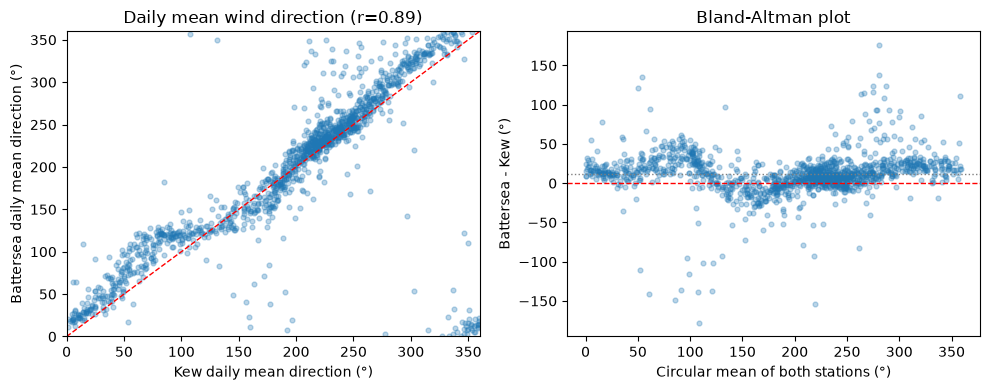

In [42]:
def angular_diff_deg(battersea_deg, kew_deg):
    """Signed shortest angular difference (Battersea - Kew) in degrees."""
    return (battersea_deg - kew_deg + 180) % 360 - 180


def circular_correlation(theta_deg, eta_deg):
    """Jammalamadaka & Sengupta (2001) circular correlation coefficient."""
    theta = np.deg2rad(theta_deg.astype(float))
    eta = np.deg2rad(eta_deg.astype(float))
    n = len(theta)
    sum_cos_t, sum_sin_t = np.sum(np.cos(theta)), np.sum(np.sin(theta))
    sum_cos_e, sum_sin_e = np.sum(np.cos(eta)), np.sum(np.sin(eta))
    numerator = (
        np.sum(np.cos(theta) * np.cos(eta))
        + np.sum(np.sin(theta) * np.sin(eta))
        - (sum_cos_t * sum_cos_e + sum_sin_t * sum_sin_e) / n
    )
    denom_t = np.sqrt(
        np.sum(np.cos(theta) ** 2) - sum_cos_t ** 2 / n
        + np.sum(np.sin(theta) ** 2) - sum_sin_t ** 2 / n
    )
    denom_e = np.sqrt(
        np.sum(np.cos(eta) ** 2) - sum_cos_e ** 2 / n
        + np.sum(np.sin(eta) ** 2) - sum_sin_e ** 2 / n
    )
    return numerator / (denom_t * denom_e)


b_dir = wind_compare['wind_direction_deg_battersea']
k_dir = wind_compare['wind_direction_deg_kew']
dir_diff = angular_diff_deg(b_dir, k_dir)
dir_bias = dir_diff.mean()
dir_rmse = np.sqrt((dir_diff ** 2).mean())
dir_mae = np.abs(dir_diff).mean()
dir_corr = circular_correlation(b_dir, k_dir)

print(f'Overlap days (PM calendar): {len(wind_compare):,}')
print(f'Wind direction circular correlation: {dir_corr:.3f}')
print(f'Mean angular bias (Battersea - Kew): {dir_bias:.2f}°')
print(f'Mean absolute angular error: {dir_mae:.2f}°')
print(f'Angular RMSE: {dir_rmse:.2f}°')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(k_dir, b_dir, alpha=0.3, s=12)
axes[0].plot([0, 360], [0, 360], 'r--', linewidth=1)
axes[0].set_xlim(0, 360)
axes[0].set_ylim(0, 360)
axes[0].set_xlabel('Kew daily mean direction (°)')
axes[0].set_ylabel('Battersea daily mean direction (°)')
axes[0].set_title(f'Daily mean wind direction (r={dir_corr:.2f})')

mean_dir = np.rad2deg(
    np.arctan2(
        np.sin(np.deg2rad(b_dir)) + np.sin(np.deg2rad(k_dir)),
        np.cos(np.deg2rad(b_dir)) + np.cos(np.deg2rad(k_dir)),
    )
) % 360
axes[1].scatter(mean_dir, dir_diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].axhline(dir_bias, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Circular mean of both stations (°)')
axes[1].set_ylabel('Battersea - Kew (°)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()

The Circular correlation between the two stations is `0.89` which is a strong positive correlation, indicating that the wind direction features from Kew Gardens are likely to be a good proxy for Battersea.

The mean angular difference is `+11.77` degrees, which indicates that on average, Battersea records wind directions that are slightly more clockwise than Kew Gardens. This bias is relatively small and manageable given this data will only be used for `2.49%` of the PM2.5 dates.

The Bland-Altman plot showed limited variance between the two stations, with the majority falling within + or - 20 degrees of the mean difference. This suggests that while there are some days with larger discrepancies, the overall agreement between the two stations is acceptable for our use case as a small missing data fill. 


In [43]:
daily_wind_features = daily_wind_features_battersea.copy()
daily_wind_features['wind_imputed_from_kew'] = False

missing_dates = pm_dates.loc[~pm_dates['date'].isin(daily_wind_features['date']), 'date']

kew_fill = daily_kew_wind_features[
    daily_kew_wind_features['date'].isin(missing_dates)
].copy()
kew_fill['wind_imputed_from_kew'] = True

daily_wind_features = (
    pd.concat([daily_wind_features, kew_fill])
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(kew_fill)} days from Kew Gardens')

Imputed 34 days from Kew Gardens


In [44]:
# sync with PM2.5 dates
daily_wind_features = daily_wind_features.merge(pm_dates, on='date', how='inner')
missing_wind = daily_wind_features[daily_wind_features['mean_wind_speed_knots'].isnull()]
print('Missing wind data for PM2.5 dates:', len(missing_wind))
#precentage of missing wind data for PM2.5 dates
missing_percentage = len(missing_wind) / len(pm_dates) * 100
print(f'Percentage of missing wind data for PM2.5 dates: {missing_percentage:.2f}%')

Missing wind data for PM2.5 dates: 0
Percentage of missing wind data for PM2.5 dates: 0.00%


#### Export:

In [45]:
# export to CSV
OUTPUT_CSV = METEOROLOGICAL_DIR / 'london_wind_features.csv'
daily_wind_features.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(daily_wind_features):,} rows to {OUTPUT_CSV}')

Exported 1,364 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_wind_features.csv


#### Visualizations:

Scatter plots and Pearson correlations between the daily features in this section and PM2.5 on overlapping dates.

Wind direction is a circular variable; the Pearson correlation below is exploratory only.


Pearson correlation with PM2.5 (Wind):
  mean_wind_speed_knots: -0.427
  wind_speed_max_knots: -0.425
  wind_speed_min_knots: -0.307
  wind_direction_deg: -0.153


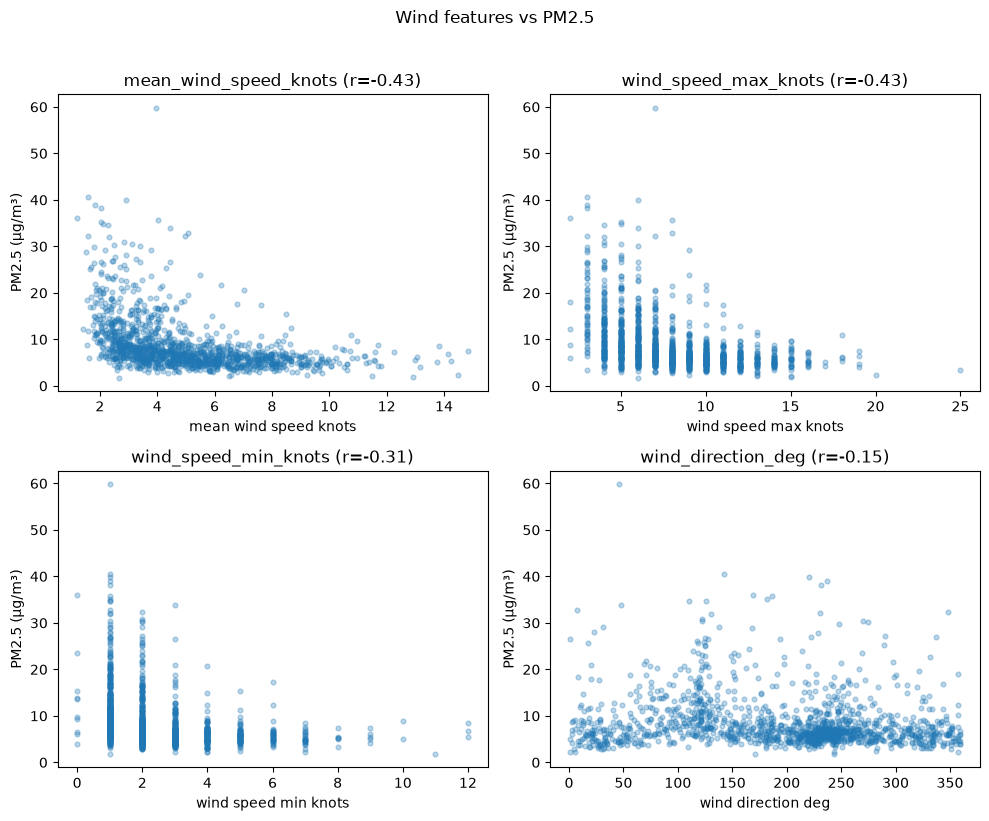

In [46]:
pm25_viz = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date', 'pm25'])
daily_wind_features_pm = daily_wind_features.merge(pm25_viz, on='date', how='inner')

feature_cols = ['mean_wind_speed_knots', 'wind_speed_max_knots', 'wind_speed_min_knots', 'wind_direction_deg']

print('Pearson correlation with PM2.5 (Wind):')
for col in feature_cols:
    r = daily_wind_features_pm[col].corr(daily_wind_features_pm['pm25'])
    print(f'  {col}: {r:.3f}')

n_cols = len(feature_cols)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_cols):
    ax.scatter(daily_wind_features_pm[col], daily_wind_features_pm['pm25'], alpha=0.3, s=12)
    r = daily_wind_features_pm[col].corr(daily_wind_features_pm['pm25'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{col} (r={r:.2f})')

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Wind features vs PM2.5', y=1.02)
plt.tight_layout()
plt.show()


In [47]:
#TODO: Correct the time span
#TODO: Align with PM2.5 data
#TODO: Make into reasonable features
#TODO: Do Air pressure

## Air Pressure:

Air pressure contains valuable information about how PM2.5 behaves in the atmosphere and dispersion of pollutants and importantly how long pollutants like PM2.5 remain suspended in the air. 

Air pressure has been assigned a relatively high attention weight in previous models.

#### References:

Zeng, L., Dong, R., Yuan, M., Jing, L., & Jiao, S. (2026). Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons. iScience, 29, 114770.


#### Met Office Data

The Met Office provides MIDAS Open hourly weather observations via CEDA. We use **Battersea Heliport** (src_id 62084) as the primary station, the closest Greater London station to London Marylebone Road (~6 km) with hourly mean sea level pressure (`msl_pressure`, hPa). Daily mean, max, and min air pressure are aggregated in the notebook.

Fetched with `features/scripts/fetch_london_pressure_battersea.py` → `data/london_pressure_hourly.csv`.

uk-hourly-weather-obs: https://data.ceda.ac.uk/badc/ukmo-midas-open/data/uk-hourly-weather-obs/

Dataset catalogue record: https://catalogue.ceda.ac.uk/uuid/99173f6a802147aeba430d96d2bb3099/

Met Office MIDAS Open UK hourly weather observations, v202507

Field documentation: https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/WH_Table.html

**Backup station — Northolt** (src_id 709), used to fill Battersea pressure gaps. Fetched with `features/scripts/fetch_london_pressure_northolt.py` → `data/london_pressure_northolt_hourly.csv`.


In [48]:
air_pressure_df = pd.read_csv(
    RAW_DATA_DIR / 'london_pressure_hourly.csv',
    parse_dates=['ob_time']
)

air_pressure_df.head()

,ob_time,src_id,msl_pressure,stn_pres,station_name,source,frequency
0,2018-05-21 00:00:00,62084,1019.8,1019.1,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
1,2018-05-21 01:00:00,62084,1019.2,1018.6,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
2,2018-05-21 02:00:00,62084,1018.7,1018.1,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
3,2018-05-21 03:00:00,62084,1018.1,1017.5,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
4,2018-05-21 04:00:00,62084,1017.9,1017.3,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly


#### Daily Aggregation:

In [49]:
air_pressure_df['date'] = pd.to_datetime(air_pressure_df['ob_time'], errors='coerce').dt.normalize() # daily time span
air_pressure_df['msl_pressure'] = pd.to_numeric(air_pressure_df['msl_pressure'], errors='coerce')

We will aggregate the hourly air pressure data to daily values to align with our PM2.5 target series. We will create a daily mean of mean sea level pressure (`msl_pressure`) to capture overall air pressure conditions for each day. We use `msl_pressure` over station pressure (`stn_pres`) as it is a more accurate representation of atmospheric pressure at sea level, which is more relevant for our PM2.5 prediction model. Station pressure is measured at the station's elevation and can be affected by local topography, so it may not reflect large-scale atmospheric pressure as cleanly.

`hPa` (hectopascals) is the unit of measurement for air pressure used here.


#### Feature creation:
- `mean_air_pressure_hpa`: the average of `msl_pressure` for each day (hectopascals).
- `air_pressure_max_hpa`: the highest `msl_pressure` for each day (hectopascals).
- `air_pressure_min_hpa`: the lowest `msl_pressure` for each day (hectopascals).


In [50]:
daily_air_pressure_features = (
    air_pressure_df.groupby('date', as_index=False) # date column is daily, so we will group by this column to get daily aggregates
    .agg(
        mean_air_pressure_hpa=('msl_pressure', 'mean'),
        hourly_obs_count=('msl_pressure', 'count'),
        air_pressure_max_hpa=('msl_pressure', 'max'),
        air_pressure_min_hpa=('msl_pressure', 'min')
    )
)

daily_air_pressure_features.head()

,date,mean_air_pressure_hpa,hourly_obs_count,air_pressure_max_hpa,air_pressure_min_hpa
0,2018-05-21,1015.966667,24,1019.8,1013.5
1,2018-05-22,1016.504167,24,1021.3,1013.9
2,2018-05-23,1022.595833,24,1023.9,1021.5
3,2018-05-24,1019.720833,24,1022.4,1017.8
4,2018-05-25,1017.854167,24,1019.3,1017.0


#### Outlier handling:

Text(0.5, 1.0, 'Daily London Average Air Pressure')

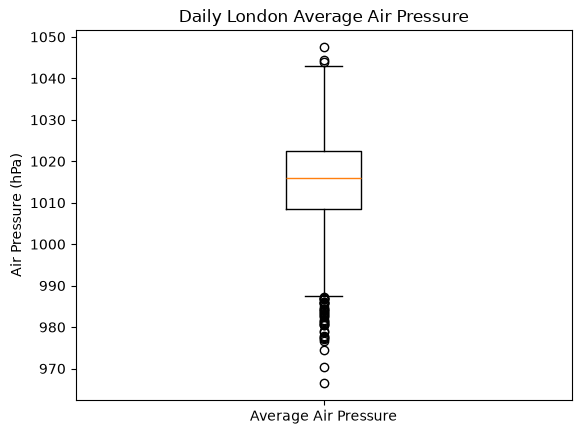

In [51]:
#plot average air pressure values in box plot
plt.boxplot(daily_air_pressure_features['mean_air_pressure_hpa'])
plt.xticks([1], ['Average Air Pressure'])
plt.ylabel('Air Pressure (hPa)')
plt.title('Daily London Average Air Pressure')

Text(0.5, 1.0, 'Daily London Max and Min Air Pressure')

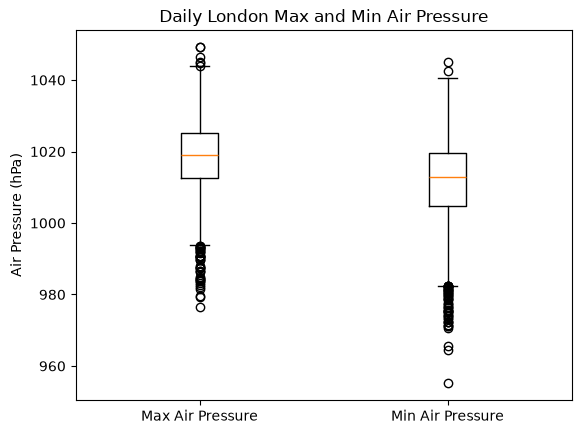

In [52]:
#plot max and min air pressure values in box plot
plt.boxplot([daily_air_pressure_features['air_pressure_max_hpa'], daily_air_pressure_features['air_pressure_min_hpa']])
plt.xticks([1, 2], ['Max Air Pressure', 'Min Air Pressure'])
plt.ylabel('Air Pressure (hPa)')
plt.title('Daily London Max and Min Air Pressure')

In [53]:
# do IQR outlier detection for air pressure features
daily_air_pressure_features['mean_air_pressure_iqr_outlier'] = flag_iqr_outliers(
    daily_air_pressure_features, 'mean_air_pressure_hpa'
)

daily_air_pressure_features['air_pressure_max_iqr_outlier'] = flag_iqr_outliers(
    daily_air_pressure_features, 'air_pressure_max_hpa'
)

daily_air_pressure_features['air_pressure_min_iqr_outlier'] = flag_iqr_outliers(
    daily_air_pressure_features, 'air_pressure_min_hpa'
)

print('Mean air pressure IQR outliers:', daily_air_pressure_features['mean_air_pressure_iqr_outlier'].sum())
print('Max air pressure IQR outliers:', daily_air_pressure_features['air_pressure_max_iqr_outlier'].sum())
print('Min air pressure IQR outliers:', daily_air_pressure_features['air_pressure_min_iqr_outlier'].sum())

Mean air pressure IQR outliers: 41
Max air pressure IQR outliers: 49
Min air pressure IQR outliers: 53


**Air pressure domain outlier sources** (900–1060 hPa on daily mean sea level pressure)

- The [CEDA UK Hourly Weather Data table](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/WH_Table.html) defines `msl_pressure` as mean sea level air pressure in **hPa** (to the nearest 0.1 hPa) — the field aggregated to daily values here.
- The Met Office records the UK's lowest verified mean sea level pressure as **925.6 hPa** (Ochtertyre, 26 January 1884) and the highest as **1053.6 hPa** (Aberdeen, 31 January 1902); see the [List of atmospheric pressure records in Europe](https://en.wikipedia.org/wiki/List_of_atmospheric_pressure_records_in_Europe#United_Kingdom).
- Daily bounds of **900–1060 hPa** are therefore generous margins around observed UK extremes; values outside this range are treated as data errors rather than real weather.

In [54]:
# domain outlier - must be between 900 and 1060 hPa
AIR_PRESSURE_MAX_THRESHOLD = 1060 # HPA
AIR_PRESSURE_MIN_THRESHOLD = 900 # HPA
for col in ['mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa']:
    if (daily_air_pressure_features[col] > AIR_PRESSURE_MAX_THRESHOLD).any():
        print(f'{col} exceeds max threshold')
    if (daily_air_pressure_features[col] < AIR_PRESSURE_MIN_THRESHOLD).any():
        print(f'{col} below min threshold')

#### Missing values:

In [55]:
missing_values = daily_air_pressure_features.isnull().sum()
print('Missing values in daily air pressure features:')
print(missing_values)

Missing values in daily air pressure features:
date                             0
mean_air_pressure_hpa            0
hourly_obs_count                 0
air_pressure_max_hpa             0
air_pressure_min_hpa             0
mean_air_pressure_iqr_outlier    0
air_pressure_max_iqr_outlier     0
air_pressure_min_iqr_outlier     0
dtype: int64


In [56]:
#check for missing date range in daily air pressure features
date_range = pd.date_range(start=daily_air_pressure_features['date'].min(), end=daily_air_pressure_features['date'].max())
missing_dates = date_range.difference(daily_air_pressure_features['date'])
print('Missing dates in daily air pressure features:', len(missing_dates))
if len(missing_dates) > 0:
    print('Missing dates range from', missing_dates.min().date(), 'to', missing_dates.max().date())

daily_air_pressure_features_battersea = daily_air_pressure_features.copy()

Missing dates in daily air pressure features: 48
Missing dates range from 2021-10-05 to 2025-05-10


In [57]:
#percentage of missing dates in Battersea air pressure features
missing_dates_battersea = date_range.difference(daily_air_pressure_features_battersea['date'])
missing_percentage_battersea = len(missing_dates_battersea) / len(date_range) * 100
print(f'Percentage of missing dates in Battersea air pressure features: {missing_percentage_battersea:.2f}%')

Percentage of missing dates in Battersea air pressure features: 1.73%


In [58]:
northolt_df = pd.read_csv(RAW_DATA_DIR / 'london_pressure_northolt_hourly.csv', parse_dates=['ob_time'])
northolt_dates = pd.to_datetime(northolt_df['ob_time']).dt.normalize().unique()

battersea_missing = pd.DatetimeIndex(missing_dates)
also_missing_at_northolt = battersea_missing[~battersea_missing.isin(northolt_dates)]
northolt_can_backfill = battersea_missing[battersea_missing.isin(northolt_dates)]

print(f'Battersea missing dates: {len(battersea_missing)}')
print(f'Also missing at Northolt: {len(also_missing_at_northolt)}')
print(f'Northolt can backfill: {len(northolt_can_backfill)}')
if len(battersea_missing) > 0:
    print(f'Range: {battersea_missing.min().date()} to {battersea_missing.max().date()}')

Battersea missing dates: 48
Also missing at Northolt: 0
Northolt can backfill: 48
Range: 2021-10-05 to 2025-05-10


Northolt is the nearest Greater London MIDAS station to Battersea that reports air pressure, we can assess the quality of the Northolt air pressure data by comparing it to Battersea on overlapping dates. This will help us determine if Northolt is a suitable proxy for Battersea in order to fill in missing Battersea air pressure data on dates where Northolt has valid readings. 

#### Northolt, same daily pipeline

Run the same hourly → daily steps on Northolt so it can be compared fairly with Battersea on overlapping dates.

In [59]:
# reuse northolt_df from backfill check above
northolt_df['date'] = pd.to_datetime(northolt_df['ob_time'], errors='coerce').dt.normalize()
northolt_df['msl_pressure'] = pd.to_numeric(northolt_df['msl_pressure'], errors='coerce')

daily_northolt_pressure_features = (
    northolt_df.groupby('date', as_index=False)
    .agg(
        mean_air_pressure_hpa=('msl_pressure', 'mean'),
        hourly_obs_count=('msl_pressure', 'count'),
        air_pressure_max_hpa=('msl_pressure', 'max'),
        air_pressure_min_hpa=('msl_pressure', 'min'),
    )
)

daily_northolt_pressure_features.head()

,date,mean_air_pressure_hpa,hourly_obs_count,air_pressure_max_hpa,air_pressure_min_hpa
0,2016-01-01,1017.008333,24,1023.1,1005.4
1,2016-01-02,998.033333,24,1004.2,994.3
2,2016-01-03,991.737500,24,1002.2,983.8
3,2016-01-04,982.662500,24,983.8,981.7
4,2016-01-05,984.641667,24,989.5,981.6


#### Compare Battersea vs Northolt (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.

Overlap days (PM calendar): 1,324
Mean pressure correlation: 0.99981
Mean bias (Battersea - Northolt): -0.20 hPa
RMSE: 0.30 hPa


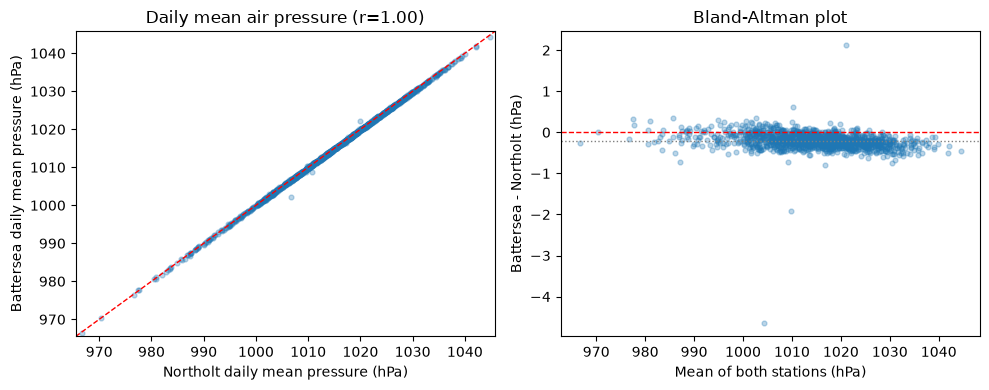

In [60]:
pressure_compare = (
    pm_dates
    .merge(daily_air_pressure_features_battersea, on='date', how='inner')
    .merge(daily_northolt_pressure_features, on='date', how='inner', suffixes=('_battersea', '_northolt'))
)

b_pres = pressure_compare['mean_air_pressure_hpa_battersea']
n_pres = pressure_compare['mean_air_pressure_hpa_northolt']
bias = (b_pres - n_pres).mean()
rmse = np.sqrt(((b_pres - n_pres) ** 2).mean())
corr = b_pres.corr(n_pres)

print(f'Overlap days (PM calendar): {len(pressure_compare):,}')
print(f'Mean pressure correlation: {corr:.5f}')
print(f'Mean bias (Battersea - Northolt): {bias:.2f} hPa')
print(f'RMSE: {rmse:.2f} hPa')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(n_pres, b_pres, alpha=0.3, s=12)
lim_min = min(b_pres.min(), n_pres.min()) - 1
lim_max = max(b_pres.max(), n_pres.max()) + 1
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1)
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_xlabel('Northolt daily mean pressure (hPa)')
axes[0].set_ylabel('Battersea daily mean pressure (hPa)')
axes[0].set_title(f'Daily mean air pressure (r={corr:.2f})')

mean_pres = (b_pres + n_pres) / 2
diff = b_pres - n_pres
axes[1].scatter(mean_pres, diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].axhline(bias, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Mean of both stations (hPa)')
axes[1].set_ylabel('Battersea - Northolt (hPa)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()

With a large overlap in days between Battersea and Northolt of `1,325` days, we can assess the quality of the Northolt air pressure data by comparing it to Battersea on overlapping dates. 

The correlation between the two stations is `0.999`, this is an extremely strong positive correlation, indicating that the air pressure features from Northolt are likely to be a very good proxy for Battersea.

The bias is `-0.20` hPa, which is the average difference between the air pressures recorded at Northolt and Battersea. This indicates that on average, Battersea records slightly lower air pressures than Northolt. However, this bias is relatively small and manageable given this data will only be used for `2.74%` of the PM2.5 dates.

The Bland-Altman plot shows their is a very small amount of variance between the two stations, with most days showing a difference of less than 1 hPa, mostly in the negative direction, which is consistent with the bias calculation. This plot suggests that while there are some days with larger discrepancies, the overall agreement between the two stations is acceptable for our use case as a small missing data fill.


In [61]:
daily_air_pressure_features = daily_air_pressure_features_battersea.copy()
daily_air_pressure_features['pressure_imputed_from_northolt'] = False

missing_dates = pm_dates.loc[~pm_dates['date'].isin(daily_air_pressure_features['date']), 'date']

northolt_fill = daily_northolt_pressure_features[
    daily_northolt_pressure_features['date'].isin(missing_dates)
].copy()
northolt_fill['pressure_imputed_from_northolt'] = True

daily_air_pressure_features = (
    pd.concat([daily_air_pressure_features, northolt_fill])
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(northolt_fill)} days from Northolt')

Imputed 40 days from Northolt


In [62]:
# sync with PM2.5 dates
daily_air_pressure_features = daily_air_pressure_features.merge(pm_dates, on='date', how='inner')
missing_pressure = daily_air_pressure_features[daily_air_pressure_features['mean_air_pressure_hpa'].isnull()]
print('Missing pressure data for PM2.5 dates:', len(missing_pressure))
missing_percentage = len(missing_pressure) / len(pm_dates) * 100
print(f'Percentage of missing pressure data for PM2.5 dates: {missing_percentage:.2f}%')

Missing pressure data for PM2.5 dates: 0
Percentage of missing pressure data for PM2.5 dates: 0.00%


#### Export:

In [63]:
# export to CSV
OUTPUT_CSV = METEOROLOGICAL_DIR / 'london_pressure_features.csv'
daily_air_pressure_features.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(daily_air_pressure_features):,} rows to {OUTPUT_CSV}')
print(f'Imputed from Northolt: {daily_air_pressure_features["pressure_imputed_from_northolt"].sum()} days')

Exported 1,364 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_pressure_features.csv
Imputed from Northolt: 40 days


#### Visualizations:

Scatter plots and Pearson correlations between the daily features in this section and PM2.5 on overlapping dates.


Pearson correlation with PM2.5 (Air pressure):
  mean_air_pressure_hpa: 0.202
  air_pressure_max_hpa: 0.194
  air_pressure_min_hpa: 0.207


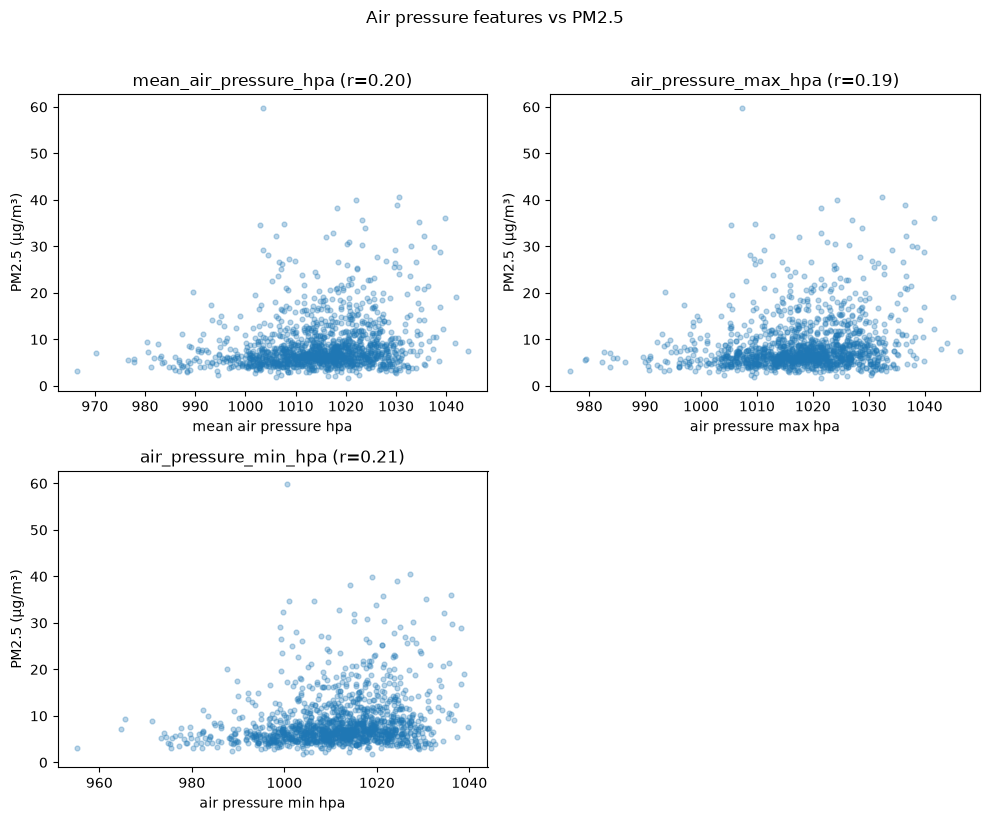

In [64]:
pm25_viz = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date', 'pm25'])
daily_air_pressure_features_pm = daily_air_pressure_features.merge(pm25_viz, on='date', how='inner')

feature_cols = ['mean_air_pressure_hpa', 'air_pressure_max_hpa', 'air_pressure_min_hpa']

print('Pearson correlation with PM2.5 (Air pressure):')
for col in feature_cols:
    r = daily_air_pressure_features_pm[col].corr(daily_air_pressure_features_pm['pm25'])
    print(f'  {col}: {r:.3f}')

n_cols = len(feature_cols)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_cols):
    ax.scatter(daily_air_pressure_features_pm[col], daily_air_pressure_features_pm['pm25'], alpha=0.3, s=12)
    r = daily_air_pressure_features_pm[col].corr(daily_air_pressure_features_pm['pm25'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{col} (r={r:.2f})')

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Air pressure features vs PM2.5', y=1.02)
plt.tight_layout()
plt.show()


In [65]:
# Humidity and precipitation comparison/backfill sections follow below.


## Precipitation and Humidity:

Humidity is often dropped from PM2.5 prediction models, but we will conduct our own analysis to determine if it is a useful feature for our use case.

The same is true for precipitation, which is often dropped from PM2.5 prediction models.

We have built these features initially as they are Meteorological features that are often used in PM2.5 prediction models, and we want to assess their usefulness for our specific use case.

References: Zeng, L., Dong, R., Yuan, M., Jing, L., & Jiao, S. (2026). Evaluating deep learning time series models for PM2.5 forecasting across diverse horizons. iScience, 29, 114770


### Humidity


The Met Office provides MIDAS Open hourly weather observations via CEDA. We use **Battersea Heliport** (src_id 62084) as the primary station (~6 km from London Marylebone Road). Relative humidity (`rltv_hum`, %) is aggregated to daily mean, max, and min values in the notebook. Dewpoint is present in the hourly MIDAS files but is not used in the daily feature set.

Source: [MIDAS Open UK hourly weather observations](https://catalogue.ceda.ac.uk/uuid/99173f6a802147aeba430d96d2bb3099/) (CEDA).

Fetched with `features/scripts/fetch_london_humidity_battersea.py` → `data/london_humidity_hourly.csv`.

**Backup station — London St James's Park** (src_id 697, ~2.6 km), used to fill Battersea humidity gaps. Fetched with `features/scripts/fetch_london_humidity_st_james_park.py` → `data/london_humidity_st_james_park_hourly.csv`.

**Second backup — Northolt** (src_id 709, ~19 km), used for dates still missing after Battersea + St James's Park (e.g. Apr–May 2025). Same station already used for pressure backfill. Fetched with `features/scripts/fetch_london_humidity_northolt.py` → `data/london_humidity_northolt_hourly.csv`.


In [66]:
humidity_df = pd.read_csv(
    RAW_DATA_DIR / 'london_humidity_hourly.csv',
    parse_dates=['ob_time']
)

humidity_df.head()

,ob_time,src_id,rltv_hum,dewpoint,station_name,source,frequency
0,2018-05-21 00:00:00,62084,84.8,8.6,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
1,2018-05-21 01:00:00,62084,87.3,8.8,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
2,2018-05-21 02:00:00,62084,87.2,8.5,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
3,2018-05-21 03:00:00,62084,87.1,8.3,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly
4,2018-05-21 04:00:00,62084,85.8,8.0,BATTERSEA HELIPORT,ceda_midas_open_202607,hourly


#### Daily Aggregation:

In [67]:
humidity_df['date'] = pd.to_datetime(humidity_df['ob_time'], errors='coerce').dt.normalize()
humidity_df['rltv_hum'] = pd.to_numeric(humidity_df['rltv_hum'], errors='coerce')
humidity_df['dewpoint'] = pd.to_numeric(humidity_df['dewpoint'], errors='coerce')

We will aggregate the hourly humidity data to daily values to align with our PM2.5 target series. We will create a daily mean of `rltv_hum` to capture overall humidity conditions for each day, along with daily max and min relative humidity. `rltv_hum` is the Met Office calculated relative humidity (%).

#### Feature creation:
- `mean_relative_humidity_pct`: the average of `rltv_hum` for each day (%).
- `relative_humidity_max_pct`: the highest `rltv_hum` for each day (%).
- `relative_humidity_min_pct`: the lowest `rltv_hum` for each day (%).


In [68]:
daily_humidity_features = (
    humidity_df.groupby('date', as_index=False)
    .agg(
        mean_relative_humidity_pct=('rltv_hum', 'mean'),
        hourly_obs_count=('rltv_hum', 'count'),
        relative_humidity_max_pct=('rltv_hum', 'max'),
        relative_humidity_min_pct=('rltv_hum', 'min'),
    )
)
# Drop days with timestamped rows but no valid humidity readings.
daily_humidity_features = daily_humidity_features[
    daily_humidity_features['hourly_obs_count'] > 0
].copy()

daily_humidity_features.head()


,date,mean_relative_humidity_pct,hourly_obs_count,relative_humidity_max_pct,relative_humidity_min_pct
0,2018-05-21,62.416667,24,87.3,40.5
1,2018-05-22,62.187500,24,79.3,47.1
2,2018-05-23,73.612500,24,82.6,58.0
3,2018-05-24,82.766667,24,90.1,69.1
4,2018-05-25,79.291667,24,88.6,67.6


#### Outlier handling:

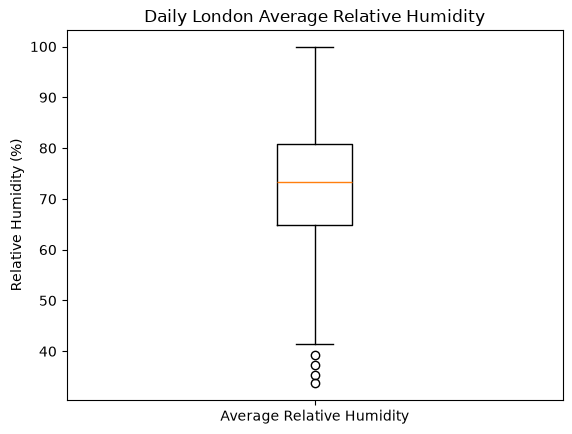

In [69]:
#plot average relative humidity values in box plot
plt.boxplot(daily_humidity_features['mean_relative_humidity_pct'].dropna())
plt.xticks([1], ['Average Relative Humidity'])
plt.ylabel('Relative Humidity (%)')
plt.title('Daily London Average Relative Humidity')
plt.show()

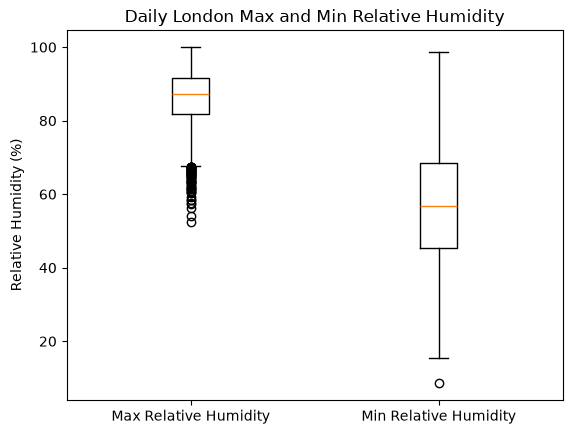

In [70]:
#plot max and min relative humidity values in box plot
plt.boxplot([
    daily_humidity_features['relative_humidity_max_pct'].dropna(),
    daily_humidity_features['relative_humidity_min_pct'].dropna(),
])
plt.xticks([1, 2], ['Max Relative Humidity', 'Min Relative Humidity'])
plt.ylabel('Relative Humidity (%)')
plt.title('Daily London Max and Min Relative Humidity')
plt.show()

In [71]:
# do IQR outlier detection for humidity features
daily_humidity_features['mean_relative_humidity_iqr_outlier'] = flag_iqr_outliers(
    daily_humidity_features, 'mean_relative_humidity_pct'
)

daily_humidity_features['relative_humidity_max_iqr_outlier'] = flag_iqr_outliers(
    daily_humidity_features, 'relative_humidity_max_pct'
)

daily_humidity_features['relative_humidity_min_iqr_outlier'] = flag_iqr_outliers(
    daily_humidity_features, 'relative_humidity_min_pct'
)

print('Mean relative humidity IQR outliers:', daily_humidity_features['mean_relative_humidity_iqr_outlier'].sum())
print('Max relative humidity IQR outliers:', daily_humidity_features['relative_humidity_max_iqr_outlier'].sum())
print('Min relative humidity IQR outliers:', daily_humidity_features['relative_humidity_min_iqr_outlier'].sum())

Mean relative humidity IQR outliers: 4
Max relative humidity IQR outliers: 58
Min relative humidity IQR outliers: 1


**Relative humidity domain outlier sources** (0–100% on daily mean relative humidity)

- The [CEDA UK Hourly Weather Data table](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/WH_Table.html) defines `rltv_hum` as calculated relative humidity.
- Relative humidity is bounded between **0%** (dry) and **100%** (saturation) by definition.
- Values outside 0–100% are therefore treated as data errors rather than real weather.

In [72]:
# domain outlier - must be between 0 and 100 %
RELATIVE_HUMIDITY_MAX_THRESHOLD = 100
RELATIVE_HUMIDITY_MIN_THRESHOLD = 0
for col in [
    'mean_relative_humidity_pct',
    'relative_humidity_max_pct',
    'relative_humidity_min_pct',
]:
    if (daily_humidity_features[col] > RELATIVE_HUMIDITY_MAX_THRESHOLD).any():
        print(f'{col} exceeds max threshold')
    if (daily_humidity_features[col] < RELATIVE_HUMIDITY_MIN_THRESHOLD).any():
        print(f'{col} below min threshold')

#### Missing values:

In [73]:
missing_values = daily_humidity_features.isnull().sum()
print('Missing values in daily humidity features:')
print(missing_values)

Missing values in daily humidity features:
date                                  0
mean_relative_humidity_pct            0
hourly_obs_count                      0
relative_humidity_max_pct             0
relative_humidity_min_pct             0
mean_relative_humidity_iqr_outlier    0
relative_humidity_max_iqr_outlier     0
relative_humidity_min_iqr_outlier     0
dtype: int64


In [74]:
#check for missing date range in daily humidity features
date_range = pd.date_range(
    start=daily_humidity_features['date'].min(),
    end=daily_humidity_features['date'].max(),
)
missing_dates = date_range.difference(daily_humidity_features['date'])
print('Missing dates in daily humidity features:', len(missing_dates))
if len(missing_dates) > 0:
    print('Missing dates range from', missing_dates.min().date(), 'to', missing_dates.max().date())

daily_humidity_features_battersea = daily_humidity_features.copy()


Missing dates in daily humidity features: 49
Missing dates range from 2021-10-05 to 2025-05-11


In [75]:
#percentage of missing dates in Battersea humidity features
missing_dates_battersea = date_range.difference(daily_humidity_features_battersea['date'])
missing_percentage_battersea = len(missing_dates_battersea) / len(date_range) * 100
print(f'Percentage of missing dates in Battersea humidity features: {missing_percentage_battersea:.2f}%')

Percentage of missing dates in Battersea humidity features: 1.76%


In [76]:
st_james_humidity_df = pd.read_csv(RAW_DATA_DIR / 'london_humidity_st_james_park_hourly.csv', parse_dates=['ob_time'])
st_james_humidity_dates = pd.to_datetime(st_james_humidity_df['ob_time']).dt.normalize().unique()

battersea_missing = pd.DatetimeIndex(missing_dates)
also_missing_at_st_james = battersea_missing[~battersea_missing.isin(st_james_humidity_dates)]
st_james_can_backfill = battersea_missing[battersea_missing.isin(st_james_humidity_dates)]

print(f'Battersea missing dates: {len(battersea_missing)}')
print(f'Also missing at St James\'s Park: {len(also_missing_at_st_james)}')
print(f'St James\'s Park can backfill: {len(st_james_can_backfill)}')
if len(battersea_missing) > 0:
    print(f'Range: {battersea_missing.min().date()} to {battersea_missing.max().date()}')


Battersea missing dates: 49
Also missing at St James's Park: 14
St James's Park can backfill: 35
Range: 2021-10-05 to 2025-05-11


London St James's Park is the nearest Greater London MIDAS hourly weather station to London Marylebone Road (~2.6 km) and reports relative humidity. We compare it to Battersea on overlapping dates to assess whether St James's Park is a suitable proxy for filling Battersea humidity gaps.


#### St James's Park, same daily pipeline

Run the same hourly → daily steps on St James's Park so it can be compared fairly with Battersea on overlapping dates.


In [77]:
# reuse st_james_humidity_df from backfill check above
st_james_humidity_df['date'] = pd.to_datetime(st_james_humidity_df['ob_time'], errors='coerce').dt.normalize()
st_james_humidity_df['rltv_hum'] = pd.to_numeric(st_james_humidity_df['rltv_hum'], errors='coerce')

daily_st_james_humidity_features = (
    st_james_humidity_df.groupby('date', as_index=False)
    .agg(
        mean_relative_humidity_pct=('rltv_hum', 'mean'),
        hourly_obs_count=('rltv_hum', 'count'),
        relative_humidity_max_pct=('rltv_hum', 'max'),
        relative_humidity_min_pct=('rltv_hum', 'min'),
    )
)
daily_st_james_humidity_features = daily_st_james_humidity_features[
    daily_st_james_humidity_features['hourly_obs_count'] > 0
].copy()

daily_st_james_humidity_features.head()


,date,mean_relative_humidity_pct,hourly_obs_count,relative_humidity_max_pct,relative_humidity_min_pct
0,2016-01-01,84.508333,24,94.6,72.6
1,2016-01-02,89.683333,24,93.7,84.8
2,2016-01-03,87.495833,24,95.4,74.9
3,2016-01-04,87.879167,24,95.4,75.1
4,2016-01-05,89.375000,24,95.7,80.4


#### Compare Battersea vs St James's Park (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.


Overlap days (PM calendar): 1,291
Mean relative humidity correlation: 0.97776
Mean bias (Battersea - St James): -1.33 %
RMSE: 2.66 %


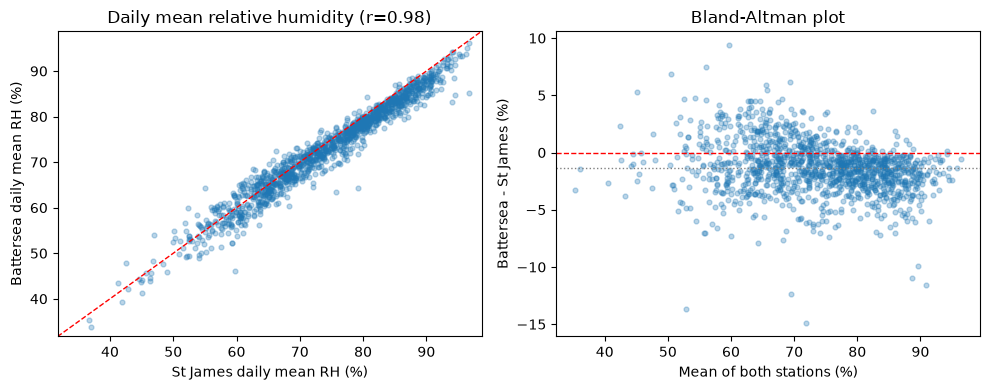

In [78]:
humidity_compare = (
    pm_dates
    .merge(daily_humidity_features_battersea, on='date', how='inner')
    .merge(daily_st_james_humidity_features, on='date', how='inner', suffixes=('_battersea', '_st_james'))
)

b_hum = humidity_compare['mean_relative_humidity_pct_battersea']
s_hum = humidity_compare['mean_relative_humidity_pct_st_james']
hum_bias = (b_hum - s_hum).mean()
hum_rmse = np.sqrt(((b_hum - s_hum) ** 2).mean())
hum_corr = b_hum.corr(s_hum)

print(f'Overlap days (PM calendar): {len(humidity_compare):,}')
print(f'Mean relative humidity correlation: {hum_corr:.5f}')
print(f'Mean bias (Battersea - St James): {hum_bias:.2f} %')
print(f'RMSE: {hum_rmse:.2f} %')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(s_hum, b_hum, alpha=0.3, s=12)
lim_min = min(b_hum.min(), s_hum.min()) - 2
lim_max = max(b_hum.max(), s_hum.max()) + 2
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1)
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)
axes[0].set_xlabel('St James daily mean RH (%)')
axes[0].set_ylabel('Battersea daily mean RH (%)')
axes[0].set_title(f'Daily mean relative humidity (r={hum_corr:.2f})')

mean_hum = (b_hum + s_hum) / 2
hum_diff = b_hum - s_hum
axes[1].scatter(mean_hum, hum_diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].axhline(hum_bias, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Mean of both stations (%)')
axes[1].set_ylabel('Battersea - St James (%)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()


The correlation between the two stations is `0.98`, this is a very strong positive correlation, indicating that the relative humidity features from St James's Park are likely to be a very good proxy for Battersea.

The bias is `-1.33%` suggesting that on average, Battersea records slightly lower relative humidity than St James's Park. However, this bias is relatively small and manageable given this data will only be used for `2.74%` of the PM2.5 dates.

The Bland-Altman plot shows their is a small amount of variance between the two stations, with most days showing a difference of less than 5%, mostly in the negative direction, which is consistent with the bias calculation. This plot suggests that while there are some days with larger discrepancies, the overall agreement between the two stations is acceptable for our use case as a small missing data fill.


In [79]:
daily_humidity_features = daily_humidity_features_battersea.copy()
daily_humidity_features['humidity_imputed_from_st_james'] = False
daily_humidity_features['humidity_imputed_from_northolt'] = False

# Include dates present but with null humidity (empty Battersea shells).
valid_dates = daily_humidity_features.loc[
    daily_humidity_features['mean_relative_humidity_pct'].notna(), 'date'
]
missing_dates = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
daily_humidity_features = daily_humidity_features[
    daily_humidity_features['mean_relative_humidity_pct'].notna()
].copy()

st_james_fill = daily_st_james_humidity_features[
    daily_st_james_humidity_features['date'].isin(missing_dates)
].copy()
st_james_fill['humidity_imputed_from_st_james'] = True
st_james_fill['humidity_imputed_from_northolt'] = False

daily_humidity_features = (
    pd.concat([daily_humidity_features, st_james_fill])
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(st_james_fill)} days from St James\'s Park')


Imputed 27 days from St James's Park


In [80]:
#remaining missing dates after St James backfill
remaining_missing_dates = pm_dates.loc[~pm_dates['date'].isin(daily_humidity_features['date']), 'date']
print(f'Remaining missing dates after St James backfill: {len(remaining_missing_dates)}')

Remaining missing dates after St James backfill: 14


#### Northolt backup for remaining humidity gaps

After Battersea + St James's Park, a short block of dates is still missing from both stations. **Northolt** (src_id 709) is the same Greater London MIDAS hourly weather station already used to backfill Battersea pressure gaps in Apr–May 2025. We apply the same station-backfill pattern here instead of linear interpolation.


In [81]:
northolt_humidity_df = pd.read_csv(
    RAW_DATA_DIR / 'london_humidity_northolt_hourly.csv',
    parse_dates=['ob_time'],
)
northolt_humidity_dates = pd.to_datetime(northolt_humidity_df['ob_time']).dt.normalize().unique()

valid_dates = daily_humidity_features.loc[
    daily_humidity_features['mean_relative_humidity_pct'].notna(), 'date'
]
remaining_missing = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
remaining_missing_idx = pd.DatetimeIndex(remaining_missing)
also_missing_at_northolt = remaining_missing_idx[~remaining_missing_idx.isin(northolt_humidity_dates)]
northolt_can_backfill = remaining_missing_idx[remaining_missing_idx.isin(northolt_humidity_dates)]

print(f'Remaining missing after St James: {len(remaining_missing_idx)}')
print(f'Also missing at Northolt: {len(also_missing_at_northolt)}')
print(f'Northolt can backfill: {len(northolt_can_backfill)}')
if len(remaining_missing_idx) > 0:
    print(f'Range: {remaining_missing_idx.min().date()} to {remaining_missing_idx.max().date()}')


Remaining missing after St James: 14
Also missing at Northolt: 0
Northolt can backfill: 14
Range: 2025-04-28 to 2025-05-11


#### Northolt, same daily pipeline

Run the same hourly → daily steps on Northolt so it can be compared fairly with Battersea on overlapping dates.


In [82]:
northolt_humidity_df['date'] = pd.to_datetime(
    northolt_humidity_df['ob_time'], errors='coerce'
).dt.normalize()
northolt_humidity_df['rltv_hum'] = pd.to_numeric(
    northolt_humidity_df['rltv_hum'], errors='coerce'
)

daily_northolt_humidity_features = (
    northolt_humidity_df.groupby('date', as_index=False)
    .agg(
        mean_relative_humidity_pct=('rltv_hum', 'mean'),
        hourly_obs_count=('rltv_hum', 'count'),
        relative_humidity_max_pct=('rltv_hum', 'max'),
        relative_humidity_min_pct=('rltv_hum', 'min'),
    )
)
daily_northolt_humidity_features = daily_northolt_humidity_features[
    daily_northolt_humidity_features['hourly_obs_count'] > 0
].copy()

daily_northolt_humidity_features.head()


,date,mean_relative_humidity_pct,hourly_obs_count,relative_humidity_max_pct,relative_humidity_min_pct
0,2016-01-01,87.641667,24,98.1,73.9
1,2016-01-02,91.312500,24,94.9,84.3
2,2016-01-03,89.395833,24,96.7,79.5
3,2016-01-04,88.354167,24,95.3,78.7
4,2016-01-05,90.758333,24,95.5,84.1


#### Compare Battersea vs Northolt (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.


Overlap days (PM calendar): 1,323
Pearson correlation: 0.969
Mean bias (Battersea - Northolt): -3.73 %
RMSE: 4.61 %


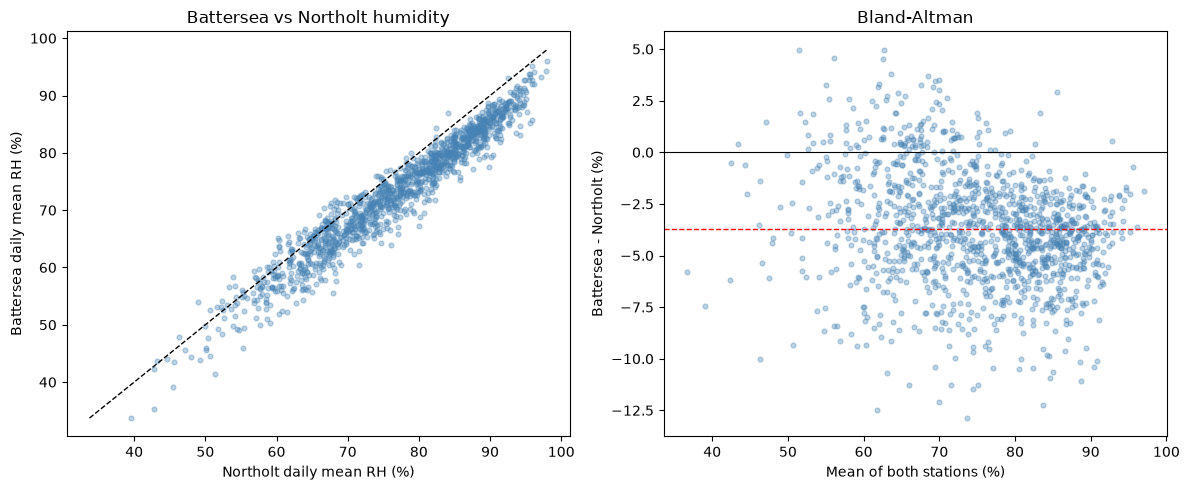

In [83]:
humidity_compare_northolt = (
    pm_dates
    .merge(daily_humidity_features_battersea, on='date', how='inner')
    .merge(
        daily_northolt_humidity_features,
        on='date',
        how='inner',
        suffixes=('_battersea', '_northolt'),
    )
)

b_hum = humidity_compare_northolt['mean_relative_humidity_pct_battersea']
n_hum = humidity_compare_northolt['mean_relative_humidity_pct_northolt']
hum_bias_n = (b_hum - n_hum).mean()
hum_rmse_n = np.sqrt(((b_hum - n_hum) ** 2).mean())
hum_corr_n = b_hum.corr(n_hum)

print(f'Overlap days (PM calendar): {len(humidity_compare_northolt):,}')
print(f'Pearson correlation: {hum_corr_n:.3f}')
print(f'Mean bias (Battersea - Northolt): {hum_bias_n:.2f} %')
print(f'RMSE: {hum_rmse_n:.2f} %')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(n_hum, b_hum, alpha=0.35, s=12, color='steelblue')
lims = [
    min(b_hum.min(), n_hum.min()),
    max(b_hum.max(), n_hum.max()),
]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Northolt daily mean RH (%)')
axes[0].set_ylabel('Battersea daily mean RH (%)')
axes[0].set_title('Battersea vs Northolt humidity')

mean_both = (b_hum + n_hum) / 2
diff = b_hum - n_hum
axes[1].scatter(mean_both, diff, alpha=0.35, s=12, color='steelblue')
axes[1].axhline(diff.mean(), color='red', linestyle='--', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean of both stations (%)')
axes[1].set_ylabel('Battersea - Northolt (%)')
axes[1].set_title('Bland-Altman')
plt.tight_layout()
plt.show()


With an overlap of `1,324` days on the PM2.5 calendar, Northolt provides a substantial amount of data to compare against Battersea.

The correlation between the two stations is `0.969`, this is a very strong positive correlation, indicating that the relative humidity features from Northolt are likely to be a good proxy for Battersea for the small set of dates still missing after St James's Park.

The bias is `-3.73%` suggesting that on average, Battersea records slightly lower relative humidity than Northolt. This bias is larger than the St James's Park comparison, but still manageable given Northolt will only be used for a short residual gap (~1% of the PM2.5 dates) where both nearer stations are unavailable.

The Bland-Altman plot shows most days fall below the zero line, consistent with the negative bias, with a modest spread around the mean difference. Overall agreement is acceptable for our use case as a limited missing-data fill.


In [84]:
valid_dates = daily_humidity_features.loc[
    daily_humidity_features['mean_relative_humidity_pct'].notna(), 'date'
]
missing_dates = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
daily_humidity_features = daily_humidity_features[
    daily_humidity_features['mean_relative_humidity_pct'].notna() # Copy the rows with valid humidity values to a new DataFrame
].copy()

northolt_fill = daily_northolt_humidity_features[
    daily_northolt_humidity_features['date'].isin(missing_dates)
].copy()
northolt_fill['humidity_imputed_from_st_james'] = False
northolt_fill['humidity_imputed_from_northolt'] = True

daily_humidity_features = (
    pd.concat([daily_humidity_features, northolt_fill]) #fill the gaps in Battersea (+ St James) humidity data with Northolt data
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(northolt_fill)} days from Northolt')


Imputed 14 days from Northolt


In [85]:
# Sync to the full PM2.5 calendar (left join keeps any remaining gaps visible).
daily_humidity_features = pm_dates.merge(daily_humidity_features, on='date', how='left')

missing_humidity = daily_humidity_features['mean_relative_humidity_pct'].isnull().sum()
print('Missing humidity data for PM2.5 dates:', missing_humidity)
print(f'Percentage of missing humidity data for PM2.5 dates: {missing_humidity / len(pm_dates) * 100:.2f}%')
print(f'Rows after sync: {len(daily_humidity_features):,} (PM calendar: {len(pm_dates):,})')


Missing humidity data for PM2.5 dates: 0
Percentage of missing humidity data for PM2.5 dates: 0.00%
Rows after sync: 1,364 (PM calendar: 1,364)


In [86]:
missing_mask = daily_humidity_features['mean_relative_humidity_pct'].isnull()
gap_ids = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
gaps = (
    daily_humidity_features.loc[missing_mask]
    .groupby(gap_ids[missing_mask])
    .agg(start=('date', 'min'), end=('date', 'max'), length=('date', 'size'))
    .reset_index(drop=True)
)

print(f'Number of gaps: {len(gaps)}')
print(gaps.to_string(index=False))
if len(gaps):
    longest = int(gaps['length'].max())
    print(f'\nLongest gap: {longest} day(s)')
else:
    print('No remaining humidity gaps after Battersea + St James + Northolt.')


Number of gaps: 0
Empty DataFrame
Columns: [start, end, length]
Index: []
No remaining humidity gaps after Battersea + St James + Northolt.


#### Export:


In [87]:
# export to CSV
OUTPUT_CSV = METEOROLOGICAL_DIR / 'london_humidity_features.csv'
daily_humidity_features.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(daily_humidity_features):,} rows to {OUTPUT_CSV}')
print(f'Imputed from St James\'s Park: {daily_humidity_features["humidity_imputed_from_st_james"].sum()} days')
print(f'Imputed from Northolt: {daily_humidity_features["humidity_imputed_from_northolt"].sum()} days')


Exported 1,364 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_humidity_features.csv
Imputed from St James's Park: 27 days
Imputed from Northolt: 14 days


#### Visualizations:

Scatter plots and Pearson correlations between the daily features in this section and PM2.5 on overlapping dates.


Pearson correlation with PM2.5 (Humidity):
  mean_relative_humidity_pct: 0.075
  relative_humidity_max_pct: 0.040
  relative_humidity_min_pct: 0.057


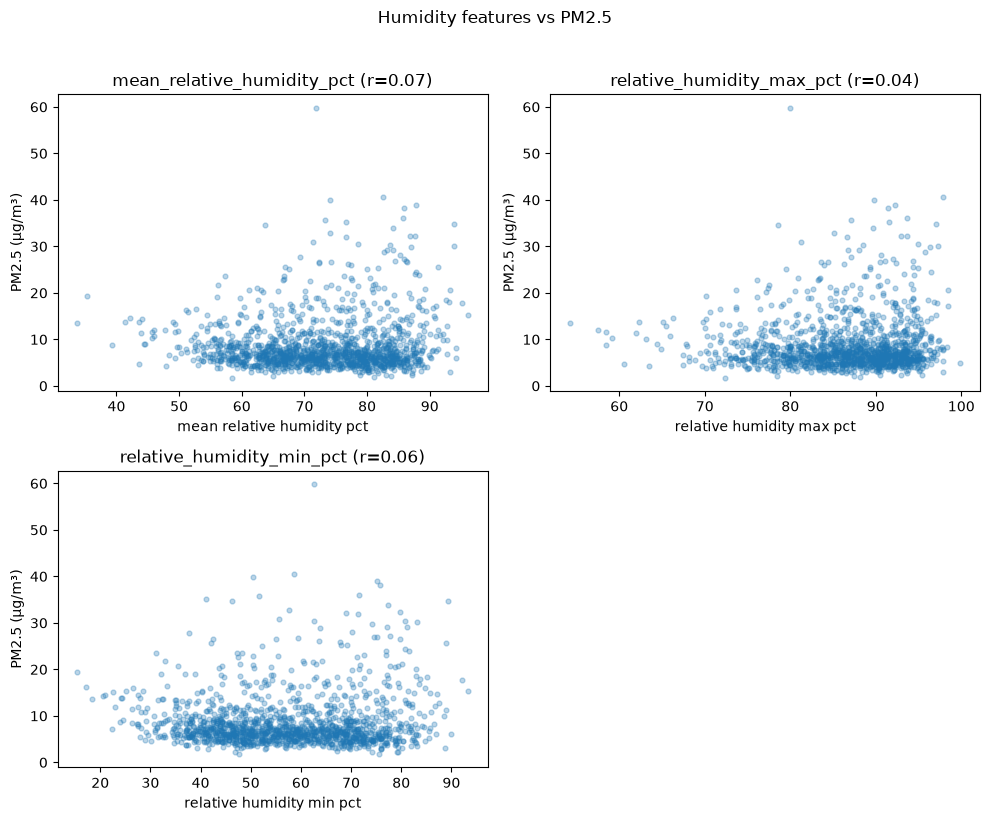

In [88]:
pm25_viz = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date', 'pm25'])
daily_humidity_features_pm = daily_humidity_features.merge(pm25_viz, on='date', how='inner')

feature_cols = ['mean_relative_humidity_pct', 'relative_humidity_max_pct', 'relative_humidity_min_pct']

print('Pearson correlation with PM2.5 (Humidity):')
for col in feature_cols:
    r = daily_humidity_features_pm[col].corr(daily_humidity_features_pm['pm25'])
    print(f'  {col}: {r:.3f}')

n_cols = len(feature_cols)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, feature_cols):
    ax.scatter(daily_humidity_features_pm[col], daily_humidity_features_pm['pm25'], alpha=0.3, s=12)
    r = daily_humidity_features_pm[col].corr(daily_humidity_features_pm['pm25'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{col} (r={r:.2f})')

for ax in axes[len(feature_cols):]:
    ax.set_visible(False)

plt.suptitle('Humidity features vs PM2.5', y=1.02)
plt.tight_layout()
plt.show()


### Precipitation

#### Met Office Data

The Met Office provides MIDAS Open hourly rainfall observations via CEDA. We use **London St James's Park** (src_id 697) as the primary station, the closest Greater London MIDAS Open hourly raingauge to London Marylebone Road (~2.6 km). Battersea Heliport does not report hourly rainfall in MIDAS Open. Hourly precipitation amount (`prcp_amt`, mm) is summed to a daily total; daily max hourly rain is also recorded.

Fetched with `features/scripts/fetch_london_precipitation_st_james_park.py` → `data/london_precipitation_st_james_park_hourly.csv`.

uk-hourly-rain-obs: https://catalogue.ceda.ac.uk/uuid/c75ca7291a5048739010380dce6ebc99/

Met Office MIDAS Open UK hourly rainfall observations (CEDA).

**Backup station — Kew Gardens** (src_id 723), used to fill St James's Park precipitation gaps. Fetched with `features/scripts/fetch_london_precipitation_kew_gardens.py` → `data/london_precipitation_kew_gardens_hourly.csv`.

**Second backup — Northolt** (src_id 709, ~19 km), used for dates still missing after St James's Park + Kew Gardens. Same station already used for pressure/humidity backfill. Fetched with `features/scripts/fetch_london_precipitation_northolt.py` → `data/london_precipitation_northolt_hourly.csv`.


In [89]:
precipitation_df = pd.read_csv(
    RAW_DATA_DIR / 'london_precipitation_st_james_park_hourly.csv',
    parse_dates=['ob_end_time']
)

precipitation_df.head()

,ob_end_time,src_id,prcp_amt,ob_hour_count,prcp_dur,station_name,source,frequency
0,2016-01-01 00:00:00,697,0.0,1,NaN,LONDON ST JAMES'S PARK,ceda_midas_open_202607,hourly
1,2016-01-01 01:00:00,697,0.0,1,NaN,LONDON ST JAMES'S PARK,ceda_midas_open_202607,hourly
2,2016-01-01 02:00:00,697,0.0,1,NaN,LONDON ST JAMES'S PARK,ceda_midas_open_202607,hourly
3,2016-01-01 03:00:00,697,0.0,1,NaN,LONDON ST JAMES'S PARK,ceda_midas_open_202607,hourly
4,2016-01-01 04:00:00,697,0.0,1,NaN,LONDON ST JAMES'S PARK,ceda_midas_open_202607,hourly


#### Daily Aggregation:

In [90]:
precipitation_df['date'] = pd.to_datetime(precipitation_df['ob_end_time'], errors='coerce').dt.normalize()
precipitation_df['prcp_amt'] = pd.to_numeric(precipitation_df['prcp_amt'], errors='coerce')
precipitation_df['prcp_dur'] = pd.to_numeric(precipitation_df['prcp_dur'], errors='coerce')

We will aggregate hourly precipitation from St James's Park to daily values to align with our PM2.5 target series. We will sum hourly `prcp_amt` to obtain daily total precipitation, and also record the daily max and min hourly amounts. `prcp_amt` is precipitation amount in millimetres (mm) from the MIDAS hourly rainfall table.

#### Create Features:
- `total_precipitation_mm`: the sum of the `prcp_amt` for each day, which will give us a daily total precipitation in millimetres.
- `precipitation_max_mm`: the highest `prcp_amt` for each day, which will give us the maximum hourly precipitation of the day.
- `precipitation_min_mm`: the lowest `prcp_amt` for each day, which will give us the minimum hourly precipitation of the day.

In [91]:
daily_precipitation_features = (
    precipitation_df.groupby('date', as_index=False)
    .agg(
        total_precipitation_mm=('prcp_amt', 'sum'),
        hourly_obs_count=('prcp_amt', 'count'),
        precipitation_max_mm=('prcp_amt', 'max'),
        precipitation_min_mm=('prcp_amt', 'min'),
    )
)

daily_precipitation_features.head()

,date,total_precipitation_mm,hourly_obs_count,precipitation_max_mm,precipitation_min_mm
0,2016-01-01,0.2,24,0.2,0.0
1,2016-01-02,4.2,24,0.8,0.0
2,2016-01-03,7.8,24,2.8,0.0
3,2016-01-04,0.4,24,0.2,0.0
4,2016-01-05,0.6,24,0.2,0.0


#### Outlier handling:

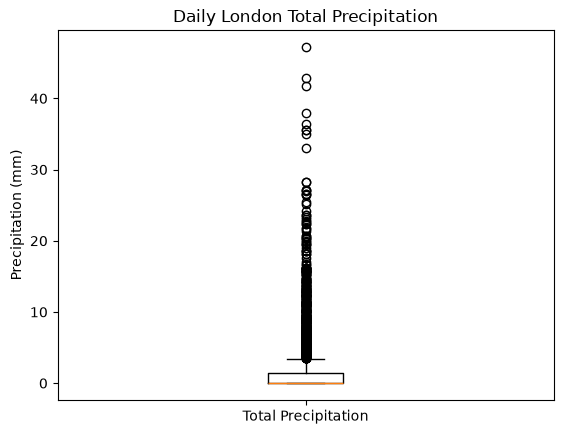

In [92]:
#plot daily total precipitation values in box plot
plt.boxplot(daily_precipitation_features['total_precipitation_mm'].dropna())
plt.xticks([1], ['Total Precipitation'])
plt.ylabel('Precipitation (mm)')
plt.title('Daily London Total Precipitation')
plt.show()

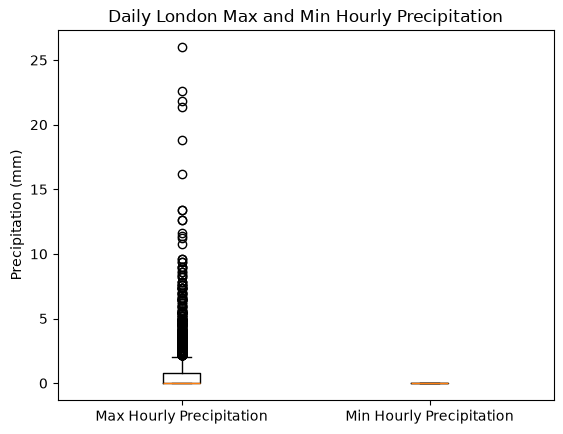

In [93]:
#plot max and min hourly precipitation values in box plot
plt.boxplot([
    daily_precipitation_features['precipitation_max_mm'].dropna(),
    daily_precipitation_features['precipitation_min_mm'].dropna(),
])
plt.xticks([1, 2], ['Max Hourly Precipitation', 'Min Hourly Precipitation'])
plt.ylabel('Precipitation (mm)')
plt.title('Daily London Max and Min Hourly Precipitation')
plt.show()

In [94]:
# do IQR outlier detection for precipitation features
daily_precipitation_features['total_precipitation_iqr_outlier'] = flag_iqr_outliers(
    daily_precipitation_features, 'total_precipitation_mm'
)

daily_precipitation_features['precipitation_max_iqr_outlier'] = flag_iqr_outliers(
    daily_precipitation_features, 'precipitation_max_mm'
)

daily_precipitation_features['precipitation_min_iqr_outlier'] = flag_iqr_outliers(
    daily_precipitation_features, 'precipitation_min_mm'
)

print('Total precipitation IQR outliers:', daily_precipitation_features['total_precipitation_iqr_outlier'].sum())
print('Max hourly precipitation IQR outliers:', daily_precipitation_features['precipitation_max_iqr_outlier'].sum())
print('Min hourly precipitation IQR outliers:', daily_precipitation_features['precipitation_min_iqr_outlier'].sum())

Total precipitation IQR outliers: 555
Max hourly precipitation IQR outliers: 384
Min hourly precipitation IQR outliers: 0


**Precipitation domain outlier sources** (0–300 mm daily total; 0–100 mm max hourly)

- The [CEDA UK Hourly Rainfall Data table](https://artefacts.ceda.ac.uk/badc_datadocs/ukmo-midas/RH_Table.html) defines `prcp_amt` as precipitation amount in **mm** (to the nearest 0.1 mm).
- The UK 24-hour rainfall record is **341.4 mm** (Honister Pass, 2015); daily totals above **300 mm** are therefore treated as data errors for London.
- Hourly amounts cannot be negative; max hourly values above **100 mm** are treated as data errors.

In [95]:
# domain outlier checks
DAILY_PRECIPITATION_MAX_THRESHOLD = 300  # mm
HOURLY_PRECIPITATION_MAX_THRESHOLD = 100  # mm
PRECIPITATION_MIN_THRESHOLD = 0  # mm

if (daily_precipitation_features['total_precipitation_mm'] > DAILY_PRECIPITATION_MAX_THRESHOLD).any():
    print('total_precipitation_mm exceeds max threshold')
if (daily_precipitation_features['total_precipitation_mm'] < PRECIPITATION_MIN_THRESHOLD).any():
    print('total_precipitation_mm below min threshold')
if (daily_precipitation_features['precipitation_max_mm'] > HOURLY_PRECIPITATION_MAX_THRESHOLD).any():
    print('precipitation_max_mm exceeds max threshold')
if (daily_precipitation_features['precipitation_min_mm'] < PRECIPITATION_MIN_THRESHOLD).any():
    print('precipitation_min_mm below min threshold')

#### Missing values:

In [96]:
missing_values = daily_precipitation_features.isnull().sum()
print('Missing values in daily precipitation features:')
print(missing_values)

Missing values in daily precipitation features:
date                               0
total_precipitation_mm             0
hourly_obs_count                   0
precipitation_max_mm               0
precipitation_min_mm               0
total_precipitation_iqr_outlier    0
precipitation_max_iqr_outlier      0
precipitation_min_iqr_outlier      0
dtype: int64


In [97]:
#check for missing date range in daily precipitation features
date_range = pd.date_range(
    start=daily_precipitation_features['date'].min(),
    end=daily_precipitation_features['date'].max(),
)
missing_dates = date_range.difference(daily_precipitation_features['date'])
print('Missing dates in daily precipitation features:', len(missing_dates))
if len(missing_dates) > 0:
    print('Missing dates range from', missing_dates.min().date(), 'to', missing_dates.max().date())

daily_precipitation_features_st_james = daily_precipitation_features.copy()


Missing dates in daily precipitation features: 53
Missing dates range from 2016-07-21 to 2025-05-14


In [98]:
kew_prcp_df = pd.read_csv(RAW_DATA_DIR / 'london_precipitation_kew_gardens_hourly.csv', parse_dates=['ob_end_time'])
kew_prcp_dates = pd.to_datetime(kew_prcp_df['ob_end_time']).dt.normalize().unique()

st_james_missing = pd.DatetimeIndex(missing_dates)
also_missing_at_kew = st_james_missing[~st_james_missing.isin(kew_prcp_dates)]
kew_can_backfill = st_james_missing[st_james_missing.isin(kew_prcp_dates)]

print(f'St James\'s Park missing dates: {len(st_james_missing)}')
print(f'Also missing at Kew Gardens: {len(also_missing_at_kew)}')
print(f'Kew Gardens can backfill: {len(kew_can_backfill)}')
if len(st_james_missing) > 0:
    print(f'Range: {st_james_missing.min().date()} to {st_james_missing.max().date()}')


St James's Park missing dates: 53
Also missing at Kew Gardens: 8
Kew Gardens can backfill: 45
Range: 2016-07-21 to 2025-05-14


In [99]:
#percentage of missing dates in St James precipitation features
missing_dates_st_james = date_range.difference(daily_precipitation_features_st_james['date'])
missing_percentage_st_james = len(missing_dates_st_james) / len(date_range) * 100
print(f'Percentage of missing dates in St James\'s Park precipitation features: {missing_percentage_st_james:.2f}%')

Percentage of missing dates in St James's Park precipitation features: 1.50%


Kew Gardens (src_id 723) is the nearest Greater London MIDAS Open hourly raingauge with continuous recent coverage that can backfill St James's Park precipitation gaps. London Weather Centre (19144) only has rainfall through 2010 in MIDAS Open. Battersea Heliport does not report hourly rainfall in MIDAS Open.


#### Kew Gardens, same daily pipeline

Run the same hourly → daily steps on Kew Gardens so it can be compared fairly with St James's Park on overlapping dates.


In [100]:
# reuse kew_prcp_df from backfill check above
kew_prcp_df['date'] = pd.to_datetime(kew_prcp_df['ob_end_time'], errors='coerce').dt.normalize()
kew_prcp_df['prcp_amt'] = pd.to_numeric(kew_prcp_df['prcp_amt'], errors='coerce')

daily_kew_precipitation_features = (
    kew_prcp_df.groupby('date', as_index=False)
    .agg(
        total_precipitation_mm=('prcp_amt', 'sum'),
        hourly_obs_count=('prcp_amt', 'count'),
        precipitation_max_mm=('prcp_amt', 'max'),
        precipitation_min_mm=('prcp_amt', 'min'),
    )
)

daily_kew_precipitation_features.head()


,date,total_precipitation_mm,hourly_obs_count,precipitation_max_mm,precipitation_min_mm
0,2016-01-01,0.4,24,0.2,0.0
1,2016-01-02,5.4,24,1.0,0.0
2,2016-01-03,7.0,24,2.4,0.0
3,2016-01-04,0.4,24,0.2,0.0
4,2016-01-05,0.2,24,0.2,0.0


#### Compare St James's Park vs Kew Gardens (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.


Overlap days (PM calendar): 1,130
Daily total precipitation correlation: 0.92795
Mean bias (St James - Kew Gardens): -0.175 mm
RMSE: 1.689 mm


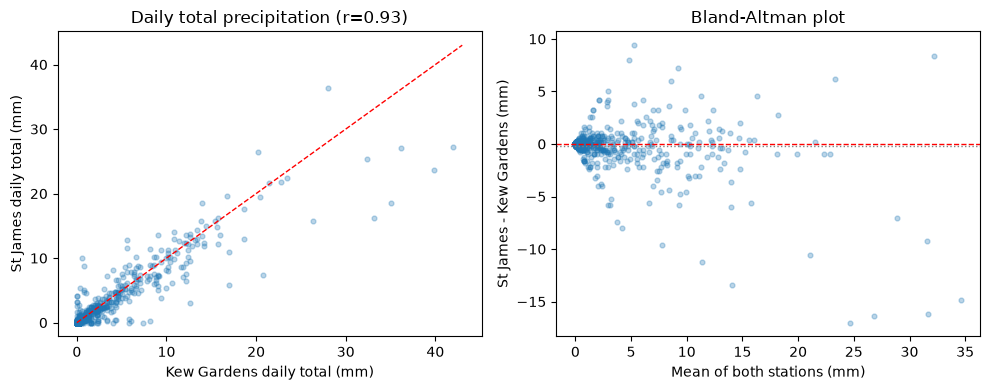

In [101]:
precip_compare = (
    pm_dates
    .merge(daily_precipitation_features_st_james, on='date', how='inner')
    .merge(daily_kew_precipitation_features, on='date', how='inner', suffixes=('_st_james', '_kew'))
)

s_prcp = precip_compare['total_precipitation_mm_st_james']
l_prcp = precip_compare['total_precipitation_mm_kew']
prcp_bias = (s_prcp - l_prcp).mean()
prcp_rmse = np.sqrt(((s_prcp - l_prcp) ** 2).mean())
prcp_corr = s_prcp.corr(l_prcp)

print(f'Overlap days (PM calendar): {len(precip_compare):,}')
print(f'Daily total precipitation correlation: {prcp_corr:.5f}')
print(f'Mean bias (St James - Kew Gardens): {prcp_bias:.3f} mm')
print(f'RMSE: {prcp_rmse:.3f} mm')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(l_prcp, s_prcp, alpha=0.3, s=12)
prcp_lim = max(s_prcp.max(), l_prcp.max()) + 1
axes[0].plot([0, prcp_lim], [0, prcp_lim], 'r--', linewidth=1)
axes[0].set_xlabel('Kew Gardens daily total (mm)')
axes[0].set_ylabel('St James daily total (mm)')
axes[0].set_title(f'Daily total precipitation (r={prcp_corr:.2f})')

mean_prcp = (s_prcp + l_prcp) / 2
prcp_diff = s_prcp - l_prcp
axes[1].scatter(mean_prcp, prcp_diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].axhline(prcp_bias, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Mean of both stations (mm)')
axes[1].set_ylabel('St James - Kew Gardens (mm)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()


With an overlap of `1,130` days, Kew Gardens provides a substantial amount of data to compare and assess the quality of the St James's Park precipitation features.

the correlation between the two stations is `0.93` which is a very strong positive correlation, indicating that the precipitation features from Kew Gardens are likely to be a very good proxy for St James's Park.

The bias figure shows that on average St James's park is slightly less rainy than Kew Gardens, with a bias of `-0.175` mm, which is a relatively small and manageable difference given this data will only be used for `2.99%` of the PM2.5 dates.

The Bland-Altman plot shows their is a small amount of variance between the two stations on average, however there are some days with larger discrepancies, with a few days showing a difference of up to 10 mm. However, a majority of the days show a difference of less than 2 mm, which is acceptable for our use case as a small missing data fill. The reason for those larger discrepancies is likely due to the fact that precipitation can be highly localized, and the two stations are not in exactly the same location.


In [102]:
daily_precipitation_features = daily_precipitation_features_st_james.copy()
daily_precipitation_features['precipitation_imputed_from_kew'] = False
daily_precipitation_features['precipitation_imputed_from_northolt'] = False

valid_dates = daily_precipitation_features.loc[
    daily_precipitation_features['total_precipitation_mm'].notna(), 'date'
]
missing_dates = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
daily_precipitation_features = daily_precipitation_features[
    daily_precipitation_features['total_precipitation_mm'].notna()
].copy()

kew_fill = daily_kew_precipitation_features[
    daily_kew_precipitation_features['date'].isin(missing_dates)
].copy()
kew_fill['precipitation_imputed_from_kew'] = True
kew_fill['precipitation_imputed_from_northolt'] = False

daily_precipitation_features = (
    pd.concat([daily_precipitation_features, kew_fill])
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(kew_fill)} days from Kew Gardens')


Imputed 57 days from Kew Gardens


In [103]:
# remaining missing dates after Kew backfill
remaining_missing_dates = pm_dates.loc[
    ~pm_dates['date'].isin(daily_precipitation_features['date']), 'date'
]
print(f'Remaining missing dates after Kew backfill: {len(remaining_missing_dates)}')


Remaining missing dates after Kew backfill: 107


#### Northolt backup for remaining precipitation gaps

After St James's Park + Kew Gardens, some PM2.5 dates are still missing precipitation (including a late-2025 tail where nearer gauges stop). **Northolt** (src_id 709) is the same Greater London MIDAS station already used for pressure/humidity backfill. We apply the same station-backfill pattern here.


In [104]:
northolt_prcp_df = pd.read_csv(
    RAW_DATA_DIR / 'london_precipitation_northolt_hourly.csv',
    parse_dates=['ob_end_time'],
)
northolt_prcp_dates = pd.to_datetime(northolt_prcp_df['ob_end_time']).dt.normalize().unique()

valid_dates = daily_precipitation_features.loc[
    daily_precipitation_features['total_precipitation_mm'].notna(), 'date'
]
remaining_missing = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
remaining_missing_idx = pd.DatetimeIndex(remaining_missing)
also_missing_at_northolt = remaining_missing_idx[~remaining_missing_idx.isin(northolt_prcp_dates)]
northolt_can_backfill = remaining_missing_idx[remaining_missing_idx.isin(northolt_prcp_dates)]

print(f'Remaining missing after Kew: {len(remaining_missing_idx)}')
print(f'Also missing at Northolt: {len(also_missing_at_northolt)}')
print(f'Northolt can backfill: {len(northolt_can_backfill)}')
if len(remaining_missing_idx) > 0:
    print(f'Range: {remaining_missing_idx.min().date()} to {remaining_missing_idx.max().date()}')


Remaining missing after Kew: 107
Also missing at Northolt: 1
Northolt can backfill: 106
Range: 2022-12-12 to 2025-12-30


#### Northolt, same daily pipeline

Run the same hourly → daily steps on Northolt so it can be compared fairly with St James's Park on overlapping dates.


In [105]:
northolt_prcp_df['date'] = pd.to_datetime(
    northolt_prcp_df['ob_end_time'], errors='coerce'
).dt.normalize()
northolt_prcp_df['prcp_amt'] = pd.to_numeric(northolt_prcp_df['prcp_amt'], errors='coerce')
if 'ob_hour_count' in northolt_prcp_df.columns:
    northolt_prcp_df['ob_hour_count'] = pd.to_numeric(
        northolt_prcp_df['ob_hour_count'], errors='coerce'
    )
    northolt_prcp_df = northolt_prcp_df[northolt_prcp_df['ob_hour_count'] == 1]

daily_northolt_precipitation_features = (
    northolt_prcp_df.groupby('date', as_index=False)
    .agg(
        total_precipitation_mm=('prcp_amt', 'sum'),
        hourly_obs_count=('prcp_amt', 'count'),
        precipitation_max_mm=('prcp_amt', 'max'),
        precipitation_min_mm=('prcp_amt', 'min'),
    )
)
daily_northolt_precipitation_features = daily_northolt_precipitation_features[
    daily_northolt_precipitation_features['hourly_obs_count'] > 0
].copy()

daily_northolt_precipitation_features.head()


,date,total_precipitation_mm,hourly_obs_count,precipitation_max_mm,precipitation_min_mm
0,2016-01-01,0.6,24,0.4,0.0
1,2016-01-02,10.0,24,2.8,0.0
2,2016-01-03,9.4,24,3.2,0.0
3,2016-01-04,0.2,24,0.2,0.0
4,2016-01-05,0.6,24,0.6,0.0


#### Compare St James's Park vs Northolt (overlap only)

Inner-join on dates where both stations have daily features, restricted to the PM2.5 calendar.


Overlap days (PM calendar): 1,198
Daily total precipitation correlation: 0.84254
Mean bias (St James - Northolt): -0.242 mm
RMSE: 2.417 mm


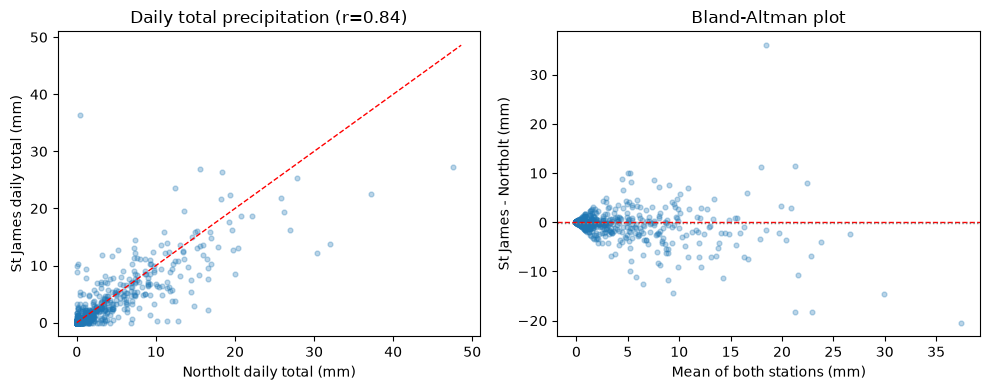

In [106]:
precip_compare_northolt = (
    pm_dates
    .merge(daily_precipitation_features_st_james, on='date', how='inner')
    .merge(
        daily_northolt_precipitation_features,
        on='date',
        how='inner',
        suffixes=('_st_james', '_northolt'),
    )
)

s_prcp = precip_compare_northolt['total_precipitation_mm_st_james']
n_prcp = precip_compare_northolt['total_precipitation_mm_northolt']
prcp_bias_n = (s_prcp - n_prcp).mean()
prcp_rmse_n = np.sqrt(((s_prcp - n_prcp) ** 2).mean())
prcp_corr_n = s_prcp.corr(n_prcp)

print(f'Overlap days (PM calendar): {len(precip_compare_northolt):,}')
print(f'Daily total precipitation correlation: {prcp_corr_n:.5f}')
print(f'Mean bias (St James - Northolt): {prcp_bias_n:.3f} mm')
print(f'RMSE: {prcp_rmse_n:.3f} mm')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(n_prcp, s_prcp, alpha=0.3, s=12)
prcp_lim = max(s_prcp.max(), n_prcp.max()) + 1
axes[0].plot([0, prcp_lim], [0, prcp_lim], 'r--', linewidth=1)
axes[0].set_xlabel('Northolt daily total (mm)')
axes[0].set_ylabel('St James daily total (mm)')
axes[0].set_title(f'Daily total precipitation (r={prcp_corr_n:.2f})')

mean_prcp = (s_prcp + n_prcp) / 2
prcp_diff = s_prcp - n_prcp
axes[1].scatter(mean_prcp, prcp_diff, alpha=0.3, s=12)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].axhline(prcp_bias_n, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Mean of both stations (mm)')
axes[1].set_ylabel('St James - Northolt (mm)')
axes[1].set_title('Bland-Altman plot')

plt.tight_layout()
plt.show()


With an overlap of `1,198` days on the PM2.5 calendar, Northolt provides a substantial amount of data to compare against St James's Park.

The correlation between the two stations is `0.84`, this is a strong positive correlation, indicating that the precipitation features from Northolt are likely to be a good proxy for St James's Park for the residual gaps left after Kew Gardens.

The bias is `-0.242` mm suggesting that on average, St James's Park records slightly less rainfall than Northolt. This difference is small and manageable given Northolt is only used where nearer gauges are unavailable.

The Bland-Altman plot shows differences centred near zero. Overall agreement is acceptable for our use case as a limited missing-data fill.


In [107]:
valid_dates = daily_precipitation_features.loc[
    daily_precipitation_features['total_precipitation_mm'].notna(), 'date'
]
missing_dates = pm_dates.loc[~pm_dates['date'].isin(valid_dates), 'date']
daily_precipitation_features = daily_precipitation_features[
    daily_precipitation_features['total_precipitation_mm'].notna()
].copy()

northolt_fill = daily_northolt_precipitation_features[
    daily_northolt_precipitation_features['date'].isin(missing_dates)
].copy()
northolt_fill['precipitation_imputed_from_kew'] = False
northolt_fill['precipitation_imputed_from_northolt'] = True

daily_precipitation_features = (
    pd.concat([daily_precipitation_features, northolt_fill])  # fill remaining gaps with Northolt
    .sort_values('date')
    .reset_index(drop=True)
)

print(f'Imputed {len(northolt_fill)} days from Northolt')


Imputed 106 days from Northolt


In [108]:
# Sync to the full PM2.5 calendar (left join keeps any remaining gaps visible).
daily_precipitation_features = pm_dates.merge(
    daily_precipitation_features, on='date', how='left'
)

missing_precipitation = daily_precipitation_features['total_precipitation_mm'].isnull().sum()
print('Missing precipitation data for PM2.5 dates:', missing_precipitation)
print(
    f'Percentage of missing precipitation data for PM2.5 dates: '
    f'{missing_precipitation / len(pm_dates) * 100:.2f}%'
)
print(f'Rows after sync: {len(daily_precipitation_features):,} (PM calendar: {len(pm_dates):,})')


Missing precipitation data for PM2.5 dates: 1
Percentage of missing precipitation data for PM2.5 dates: 0.07%
Rows after sync: 1,364 (PM calendar: 1,364)


In [109]:
missing_mask = daily_precipitation_features['total_precipitation_mm'].isnull()
gap_ids = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
gaps = (
    daily_precipitation_features.loc[missing_mask]
    .groupby(gap_ids[missing_mask])
    .agg(start=('date', 'min'), end=('date', 'max'), length=('date', 'size'))
    .reset_index(drop=True)
)

print(f'Number of gaps: {len(gaps)}')
print(gaps.to_string(index=False))
if len(gaps):
    longest = int(gaps['length'].max())
    print(f'\nLongest gap: {longest} day(s)')
else:
    print('No remaining precipitation gaps after St James + Kew + Northolt.')


Number of gaps: 1
     start        end  length
2022-12-12 2022-12-12       1

Longest gap: 1 day(s)


One PM2.5 date remains missing after St James's Park + Kew Gardens + Northolt (`2022-12-12`), with no hourly rainfall at any of the three gauges. Because this is a single day, we fill it with linear interpolation from neighbouring days. Unlike the Kew and Northolt station fills, this single interpolated day is not given a separate imputation flag in the precipitation feature CSV.


In [110]:
value_cols = [
    'total_precipitation_mm',
    'precipitation_max_mm',
    'precipitation_min_mm',
]

daily_precipitation_features = daily_precipitation_features.sort_values('date').reset_index(drop=True)
for col in value_cols:
    daily_precipitation_features[col] = daily_precipitation_features[col].interpolate(
        method='linear', limit_direction='both'
    )

daily_precipitation_features['precipitation_imputed_from_kew'] = (
    daily_precipitation_features['precipitation_imputed_from_kew'].fillna(False)
)
daily_precipitation_features['precipitation_imputed_from_northolt'] = (
    daily_precipitation_features['precipitation_imputed_from_northolt'].fillna(False)
)

missing_after = daily_precipitation_features['total_precipitation_mm'].isnull().sum()
print('Missing precipitation data for PM2.5 dates after interpolation:', missing_after)
print(f'Rows: {len(daily_precipitation_features):,}')


Missing precipitation data for PM2.5 dates after interpolation: 0
Rows: 1,364


#### Export:


In [111]:
# export to CSV
OUTPUT_CSV = METEOROLOGICAL_DIR / 'london_precipitation_features.csv'
daily_precipitation_features.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(daily_precipitation_features):,} rows to {OUTPUT_CSV}')
print(f'Imputed from Kew Gardens: {daily_precipitation_features["precipitation_imputed_from_kew"].sum()} days')
print(f'Imputed from Northolt: {daily_precipitation_features["precipitation_imputed_from_northolt"].sum()} days')


Exported 1,364 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_precipitation_features.csv
Imputed from Kew Gardens: 57 days
Imputed from Northolt: 106 days


#### Visualizations:

Scatter plots and Pearson correlations between the daily features in this section and PM2.5 on overlapping dates.

`precipitation_min_mm` is the minimum hourly rainfall in each day, which is 0 mm on almost all days (dry hours), so it has no variance and Pearson *r* is not defined.


Pearson correlation with PM2.5 (Precipitation):
  total_precipitation_mm: -0.149
  precipitation_max_mm: -0.142
  precipitation_min_mm: n/a (constant — no variance)
Excluded from plots (constant): precipitation_min_mm


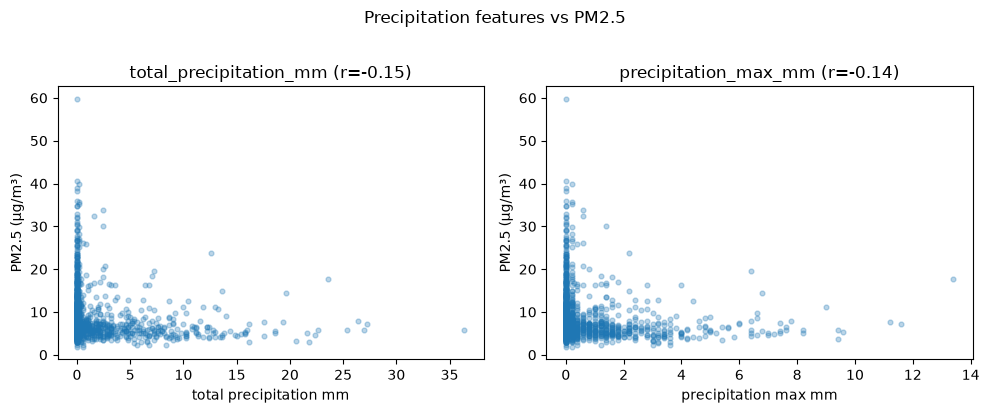

In [112]:
pm25_viz = pd.read_csv(PM25_CSV, parse_dates=['date'], usecols=['date', 'pm25'])
daily_precipitation_features_pm = daily_precipitation_features.merge(pm25_viz, on='date', how='inner')

feature_cols = ['total_precipitation_mm', 'precipitation_max_mm', 'precipitation_min_mm']
plot_cols = [
    col for col in feature_cols
    if daily_precipitation_features_pm[col].nunique(dropna=True) > 1
]
skipped_cols = [col for col in feature_cols if col not in plot_cols]

print('Pearson correlation with PM2.5 (Precipitation):')
for col in feature_cols:
    if col in skipped_cols:
        print(f'  {col}: n/a (constant — no variance)')
        continue
    r = daily_precipitation_features_pm[col].corr(daily_precipitation_features_pm['pm25'])
    print(f'  {col}: {r:.3f}')

if skipped_cols:
    print('Excluded from plots (constant):', ', '.join(skipped_cols))

n_cols = max(len(plot_cols), 1)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, plot_cols):
    ax.scatter(
        daily_precipitation_features_pm[col],
        daily_precipitation_features_pm['pm25'],
        alpha=0.3,
        s=12,
    )
    r = daily_precipitation_features_pm[col].corr(daily_precipitation_features_pm['pm25'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{col} (r={r:.2f})')

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.suptitle('Precipitation features vs PM2.5', y=1.02)
plt.tight_layout()
plt.show()


## Model-ready meteorological export

Combine the per-variable feature CSVs into one modelling table. Keep only the measured daily features; drop IQR outlier flags, imputation flags, and `hourly_obs_count`. Those diagnostics remain in the separate `london_*_features.csv` files.


In [113]:
drop_patterns = ("iqr_outlier", "imputed", "hourly_obs_count")

meteo_model_df = None
for csv_path in sorted(METEOROLOGICAL_DIR.glob("london_*_features.csv")):
    if csv_path.name == "london_meteorological_features.csv":
        continue
    part = pd.read_csv(csv_path, parse_dates=["date"])
    keep = ["date"] + [
        c for c in part.columns
        if c != "date" and not any(p in c for p in drop_patterns)
    ]
    part = part[keep]
    meteo_model_df = part if meteo_model_df is None else meteo_model_df.merge(part, on="date", how="outer")

meteo_model_df = meteo_model_df.sort_values("date").reset_index(drop=True)

OUTPUT_CSV = METEOROLOGICAL_DIR / "london_meteorological_features.csv"
meteo_model_df.to_csv(OUTPUT_CSV, index=False)
print(f"Exported {len(meteo_model_df):,} rows to {OUTPUT_CSV}")
print(meteo_model_df.isna().sum())
meteo_model_df.head()


Exported 1,364 rows to /Users/matthewbutler/Documents/MastersPaper/code/features/meteorological/london_meteorological_features.csv
date                            0
mean_relative_humidity_pct      0
relative_humidity_max_pct       0
relative_humidity_min_pct       0
total_precipitation_mm          0
precipitation_max_mm            0
precipitation_min_mm            0
mean_air_pressure_hpa           0
air_pressure_max_hpa            0
air_pressure_min_hpa            0
temperature_max_c             364
temperature_min_c             364
temperature_avg_c             364
mean_wind_speed_knots           0
wind_speed_max_knots            0
wind_speed_min_knots            0
wind_direction_deg              0
dtype: int64


,date,mean_relative_humidity_pct,relative_humidity_max_pct,relative_humidity_min_pct,total_precipitation_mm,precipitation_max_mm,precipitation_min_mm,mean_air_pressure_hpa,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
0,2022-04-07,58.950000,89.1,34.7,4.4,2.2,0.0,989.808333,1000.9,983.9,13.59557,6.81938,10.207475,13.000000,16.0,4.0,270.636089
1,2022-04-08,59.783333,79.3,37.0,0.0,0.0,0.0,1000.825000,1008.6,997.8,11.34880,1.85679,6.602795,4.291667,9.0,1.0,16.779591
2,2022-04-09,56.104167,86.4,32.0,0.0,0.0,0.0,1015.245833,1019.1,1009.7,12.37745,0.58838,6.482915,5.458333,9.0,3.0,306.186614
3,2022-04-10,49.991667,75.2,30.7,0.0,0.0,0.0,1018.666667,1020.3,1016.2,13.32986,-0.20732,6.561270,2.916667,5.0,1.0,160.738319
4,2022-04-11,51.479167,70.6,26.5,0.0,0.0,0.0,1009.812500,1015.9,1005.9,17.46161,5.02425,11.242930,3.500000,7.0,1.0,119.167789
